# 06 — Étude Complète QMKL : Bayesian Optimization, Scaling, Multi-Dataset

Étude approfondie du QMKL avec :
- **12 kernels** (bibliothèque standard diversifiée)
- **6 méthodes MKL** : Single-Best, Average, Centered, SDP, Projection, **BO-MKQSVM**
- **3 datasets financiers** + **1 dataset quantum-native** (Huang et al. 2021)
- **Scaling jusqu'à 8 qubits** + **Learning curves** (N = 30 à 250)
- **20 figures** d'analyse

### Paramètres optimisés pour exécution locale (~30-40 min)
| Paramètre | Valeur | Raison |
|---|---|---|
| N_SAMPLES | 100 | Réduit le nombre de circuits de 6× |
| N_KERNELS | 12 | Diversifié mais rapide |
| QUBIT_RANGE | [2,4,6,8] | q≥10 = heures de calcul |
| BO n_calls | 30 | Convergence atteinte en ~20 iter |
| CV folds | 3 | Bon compromis variance/vitesse |

### Table des figures
| # | Description |
|---|-------------|
| F1 | Grille de heatmaps de kernels sélectionnés |
| F2 | Alignement kernel-target (ranking) |
| F3 | Comparaison 6 méthodes × 3 datasets (barres groupées) |
| F4 | Radar chart multi-métriques |
| F5 | Convergence BO par dataset |
| F6 | Sensibilité BO : n_calls vs AUC |
| F7 | Poids BO vs Centered (scatter) |
| F8 | Scaling n_qubits avec CI95 |
| F9 | Heatmap concentration (n_qubits × kernel) |
| F10 | Heatmap poids (méthode × kernel) |
| F11 | Violin plots stabilité des poids |
| F12 | Concentration vs performance (scatter) |
| F13 | Fidelity vs Projected |
| F14 | Panel de synthèse 2×3 |
| F15 | Tests statistiques pairwise (Wilcoxon + Cohen's d) |
| F16 | Baseline classique vs Quantique |
| F17 | Dataset quantum-native : visualisation |
| F18 | Quantum vs Classical sur données quantum-native |
| F19 | Avantage quantique vs n_qubits (scaling) |
| F20 | Learning curves : performance vs N échantillons |

In [28]:
import sys, os, time, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score

from data.loaders import load_dataset
from src.preprocessing import QuantumScaler, FeatureReducer
from src.kernels import build_feature_map, build_quantum_kernel, compute_kernel_matrix
from src.kernels.kernel_matrix import compute_kernel_matrix_parallel, kernel_statistics, cache_info
from src.kernels.feature_maps import get_feature_map_library
from src.mkl.alignment import centered_alignment, sdp_alignment, projection_alignment
from src.mkl.bayesian_optimizer import BayesianKernelOptimizer
from src.evaluation.visualization import (
    plot_method_comparison_grouped, plot_bo_convergence, plot_weight_heatmap,
    plot_scaling_curve, plot_concentration_scatter, plot_radar_chart,
    _kernel_off_diagonal_stats,
)

os.makedirs('../results/06', exist_ok=True)
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)

# ── Paramètres globaux ───────────────────────────
N_SAMPLES = 100     # Réduit pour exécution rapide (100² = 10K circuits vs 250² = 62.5K)
N_QUBITS  = 6       # Dimension PCA par défaut
N_CV      = 3       # Folds cross-validation
BO_CALLS  = 30      # Itérations Bayesian Optimization

info = cache_info()
print(f'Cache : {info["files"]} fichiers ({info["total_size_mb"]:.1f} MB)')
print(f'Config : N={N_SAMPLES}, q={N_QUBITS}, CV={N_CV}-fold, BO={BO_CALLS} calls')
T_START = time.time()

Cache : 242 fichiers (27.0 MB)
Config : N=100, q=6, CV=3-fold, BO=30 calls


## §1 — Chargement des 3 datasets

In [29]:
DATASETS = {}
for name in ['german_credit', 'bank_marketing', 'synthetic']:
    X, y = load_dataset(name, n_samples=N_SAMPLES, random_state=SEED)
    reducer = FeatureReducer(n_components=N_QUBITS)
    scaler  = QuantumScaler(feature_range=(0, 2))
    X_proc = scaler.fit_transform(reducer.fit_transform(X))
    DATASETS[name] = {'X': X_proc, 'y': y, 'X_raw': X}
    print(f'{name:20s}: X={X_proc.shape}, classes={np.bincount(y)}')

print(f'\n[{time.time()-T_START:.0f}s] Datasets chargés')

german_credit       : X=(100, 6), classes=[30 70]
bank_marketing      : X=(100, 6), classes=[88 12]
synthetic           : X=(100, 6), classes=[60 40]

[1s] Datasets chargés


## §2 — Bibliothèque de 12 kernels + précalcul

In [30]:
# Build 12 kernels (standard library: 6 types × 2 alphas)
fm_lib = get_feature_map_library(N_QUBITS)
KNAMES = list(fm_lib.keys())
print(f'{len(KNAMES)} feature maps : {KNAMES}\n')

# Precompute all kernel matrices per dataset (cached on disk)
KERNELS = {}  # {dataset: list of K_full}
for ds_name, ds in DATASETS.items():
    t0 = time.time()
    qk_list = [build_quantum_kernel(fm, kernel_type='fidelity') for fm in fm_lib.values()]
    K_list = compute_kernel_matrix_parallel(
        qk_list, ds['X'],
        kernel_names=[f'{ds_name}_fid_{n}' for n in KNAMES],
        n_jobs=-1
    )
    KERNELS[ds_name] = K_list
    dt = time.time() - t0
    print(f'  {ds_name}: {len(K_list)} matrices in {dt:.1f}s')

print(f'\n[{time.time()-T_START:.0f}s] Kernel matrices computed')
print(f'Cache : {cache_info()["files"]} fichiers ({cache_info()["total_size_mb"]:.1f} MB)')

12 feature maps : ['Z_a1.0', 'Z_a3.0', 'ZZ_a1.0', 'ZZ_a4.0', 'pauli_a0.6', 'pauli_a3.0', 'pauli_XZ_a0.5', 'pauli_XZ_a2.5', 'pauli_YXX_a0.6', 'pauli_YXX_a3.0', 'pauli_YZX_a0.6', 'pauli_YZX_a3.0']

  german_credit: 12 matrices in 0.2s
  bank_marketing: 12 matrices in 0.0s
  synthetic: 12 matrices in 0.0s

[1s] Kernel matrices computed
Cache : 242 fichiers (27.0 MB)


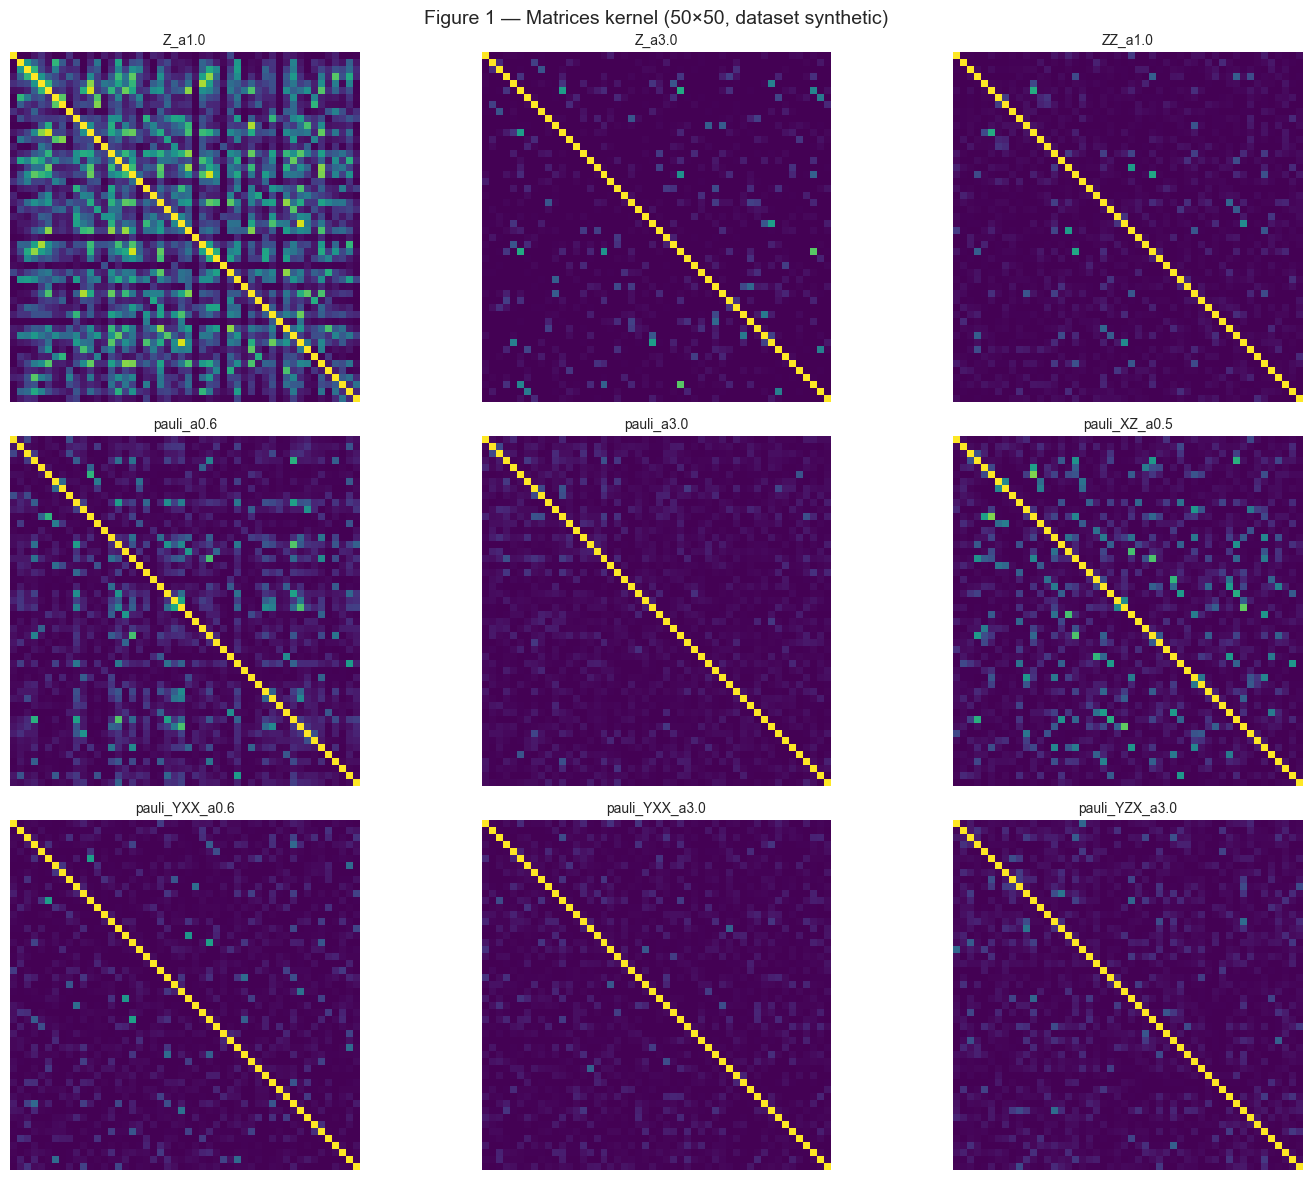

In [31]:
# ── FIGURE 1 : Grille 3×3 de heatmaps de kernels sélectionnés ───────────────
n_show = min(9, len(KNAMES))
sample_idx = np.linspace(0, len(KNAMES)-1, n_show, dtype=int)
nrows = (n_show + 2) // 3
fig, axes = plt.subplots(nrows, 3, figsize=(15, 4*nrows))
for ax_idx, (ax, kidx) in enumerate(zip(axes.flat, sample_idx)):
    K = KERNELS['synthetic'][kidx]
    n_show_px = min(50, K.shape[0])
    sns.heatmap(K[:n_show_px, :n_show_px], cmap='viridis', ax=ax, cbar=False, square=True)
    ax.set_title(KNAMES[kidx], fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
# Hide unused axes
for ax in axes.flat[n_show:]:
    ax.set_visible(False)
plt.suptitle(f'Figure 1 — Matrices kernel ({n_show_px}×{n_show_px}, dataset synthetic)', fontsize=14)
plt.tight_layout()
plt.savefig('../results/06/F01_kernel_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

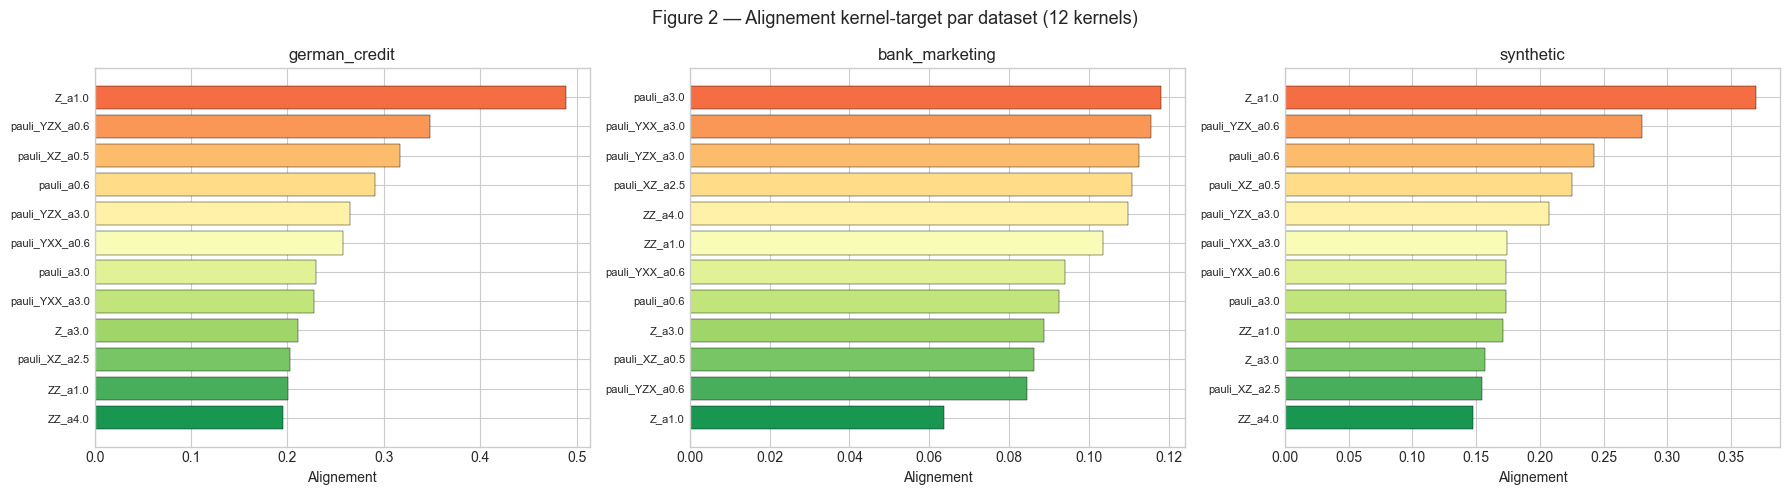

[3s] Figures 1-2 done


In [32]:
# ── FIGURE 2 : Alignement kernel-target ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (ds_name, ds) in zip(axes, DATASETS.items()):
    Ky = np.outer(ds['y'], ds['y']).astype(float)
    aligns = []
    for K in KERNELS[ds_name]:
        num = np.sum(K * Ky)
        denom = np.linalg.norm(K, 'fro') * np.linalg.norm(Ky, 'fro')
        aligns.append(num / denom if denom > 0 else 0)
    order = np.argsort(aligns)[::-1]
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(KNAMES)))
    ax.barh(range(len(KNAMES)), [aligns[i] for i in order],
            color=[colors[j] for j in range(len(KNAMES))], edgecolor='black', linewidth=0.3)
    ax.set_yticks(range(len(KNAMES)))
    ax.set_yticklabels([KNAMES[i] for i in order], fontsize=8)
    ax.set_xlabel('Alignement')
    ax.set_title(ds_name)
    ax.invert_yaxis()

plt.suptitle(f'Figure 2 — Alignement kernel-target par dataset ({len(KNAMES)} kernels)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/06/F02_alignment_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[{time.time()-T_START:.0f}s] Figures 1-2 done')

## §3 — Comparaison des 6 méthodes MKL

In [33]:
def evaluate_method(K_list, y, weight_fn, n_folds=N_CV, C=1.0, seed=SEED):
    """Evaluate an MKL method via stratified K-fold CV."""
    n = len(y)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    all_metrics = {'auc': [], 'acc': [], 'f1': [], 'prec': [], 'recall': []}
    all_weights = []

    for idx_tr, idx_te in skf.split(np.zeros(n), y):
        y_tr, y_te = y[idx_tr], y[idx_te]
        K_tr = [K[np.ix_(idx_tr, idx_tr)] for K in K_list]
        K_te = [K[np.ix_(idx_te, idx_tr)] for K in K_list]

        w = weight_fn(K_tr, y_tr)
        w = np.array(w)
        if w.sum() > 0: w = w / w.sum()
        else: w = np.ones(len(K_list)) / len(K_list)
        all_weights.append(w)

        Kc_tr = sum(wi * K for wi, K in zip(w, K_tr))
        Kc_te = sum(wi * K for wi, K in zip(w, K_te))
        ev = np.linalg.eigvalsh(Kc_tr)
        if ev.min() < 0:
            Kc_tr += (abs(ev.min()) + 1e-10) * np.eye(Kc_tr.shape[0])

        svm = SVC(kernel='precomputed', C=C, probability=True)
        svm.fit(Kc_tr, y_tr)
        y_pred  = svm.predict(Kc_te)
        y_proba = svm.predict_proba(Kc_te)[:, 1]

        all_metrics['auc'].append(roc_auc_score(y_te, y_proba))
        all_metrics['acc'].append(accuracy_score(y_te, y_pred))
        all_metrics['f1'].append(f1_score(y_te, y_pred, zero_division=0))
        all_metrics['prec'].append(precision_score(y_te, y_pred, zero_division=0))
        all_metrics['recall'].append(recall_score(y_te, y_pred, zero_division=0))

    return {
        'mean': float(np.mean(all_metrics['auc'])),
        'std':  float(np.std(all_metrics['auc'], ddof=1)),
        'scores': all_metrics['auc'],
        'all_metrics': {k: float(np.mean(v)) for k, v in all_metrics.items()},
        'mean_weights': np.mean(all_weights, axis=0),
    }


# ── Weight functions ──────────────────────────────────────
def weight_fn_single_best(K_list, y_tr):
    Ky = np.outer(y_tr, y_tr).astype(float)
    aligns = [np.sum(K * Ky) / (np.linalg.norm(K,'fro') * np.linalg.norm(Ky,'fro') + 1e-10)
              for K in K_list]
    w = np.zeros(len(K_list)); w[np.argmax(aligns)] = 1.0
    return w

def weight_fn_average(K_list, y_tr):
    return np.ones(len(K_list)) / len(K_list)

def weight_fn_centered(K_list, y_tr):
    return centered_alignment(K_list, np.outer(y_tr, y_tr).astype(float))

def weight_fn_sdp(K_list, y_tr):
    return sdp_alignment(K_list, np.outer(y_tr, y_tr).astype(float))

def weight_fn_projection(K_list, y_tr):
    return projection_alignment(K_list, np.outer(y_tr, y_tr).astype(float))


def evaluate_bo(K_list, y, n_folds=N_CV, n_calls=BO_CALLS, seed=SEED):
    """BO-MKQSVM evaluation with convergence tracking."""
    n = len(y)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    all_auc, all_weights, bo_histories = [], [], []

    for fold_i, (idx_tr, idx_te) in enumerate(skf.split(np.zeros(n), y)):
        y_tr, y_te = y[idx_tr], y[idx_te]
        K_tr = [K[np.ix_(idx_tr, idx_tr)] for K in K_list]
        K_te = [K[np.ix_(idx_te, idx_tr)] for K in K_list]

        bo = BayesianKernelOptimizer(n_calls=n_calls, n_initial_points=10,
                                     cv_folds=3, random_state=seed)
        w, C = bo.optimize(K_tr, y_tr, scoring='accuracy')
        bo_histories.append(bo.get_convergence_history())
        all_weights.append(w)

        Kc_tr = sum(wi * K for wi, K in zip(w, K_tr))
        Kc_te = sum(wi * K for wi, K in zip(w, K_te))
        ev = np.linalg.eigvalsh(Kc_tr)
        if ev.min() < 0:
            Kc_tr += (abs(ev.min()) + 1e-10) * np.eye(Kc_tr.shape[0])

        svm = SVC(kernel='precomputed', C=C, probability=True)
        svm.fit(Kc_tr, y_tr)
        auc = roc_auc_score(y_te, svm.predict_proba(Kc_te)[:, 1])
        all_auc.append(auc)
        print(f'    fold {fold_i+1}/{n_folds}: AUC={auc:.4f}')

    return {
        'mean': float(np.mean(all_auc)),
        'std':  float(np.std(all_auc, ddof=1)),
        'scores': all_auc,
        'mean_weights': np.mean(all_weights, axis=0),
        'bo_histories': bo_histories,
    }

print('Fonctions d\'évaluation prêtes')

Fonctions d'évaluation prêtes


In [34]:
# ── Run all methods on all datasets ───────────────────────────────────────────
METHODS_SIMPLE = {
    'Single-Best': weight_fn_single_best,
    'Average':     weight_fn_average,
    'Centered':    weight_fn_centered,
    'SDP':         weight_fn_sdp,
    'Projection':  weight_fn_projection,
}

ALL_RESULTS = {}
BO_HISTORIES = {}

for ds_name in DATASETS:
    print(f'\n{"="*50}  {ds_name}  {"="*50}')
    K_list = KERNELS[ds_name]
    y = DATASETS[ds_name]['y']
    ALL_RESULTS[ds_name] = {}

    for method_name, wfn in METHODS_SIMPLE.items():
        t0 = time.time()
        res = evaluate_method(K_list, y, wfn)
        ALL_RESULTS[ds_name][method_name] = res
        print(f'  {method_name:15s}: AUC = {res["mean"]:.4f} +/- {res["std"]:.4f}  ({time.time()-t0:.1f}s)')

    # Bayesian Optimization
    print(f'  {"BO":15s}: running {BO_CALLS} iterations...')
    t0 = time.time()
    bo_res = evaluate_bo(K_list, y)
    ALL_RESULTS[ds_name]['BO'] = {
        'mean': bo_res['mean'], 'std': bo_res['std'],
        'scores': bo_res['scores'], 'mean_weights': bo_res['mean_weights'],
        'all_metrics': None,  # filled below if needed
    }
    BO_HISTORIES[ds_name] = bo_res['bo_histories']
    print(f'  {"BO":15s}: AUC = {bo_res["mean"]:.4f} +/- {bo_res["std"]:.4f}  ({time.time()-t0:.1f}s)')

print(f'\n[{time.time()-T_START:.0f}s] Toutes les méthodes évaluées !')


==================================================  german_credit  ==================================================
  Single-Best    : AUC = 0.3356 +/- 0.2901  (0.0s)
  Average        : AUC = 0.6830 +/- 0.0613  (0.0s)
  Centered       : AUC = 0.5187 +/- 0.1069  (0.0s)
  SDP            : AUC = 0.5443 +/- 0.3538  (0.0s)
  Projection     : AUC = 0.5523 +/- 0.3225  (0.1s)
  BO             : running 30 iterations...
    fold 1/3: AUC=0.6292
    fold 2/3: AUC=0.7391
    fold 3/3: AUC=0.6391
  BO             : AUC = 0.6691 +/- 0.0608  (15.4s)

==================================================  bank_marketing  ==================================================
  Single-Best    : AUC = 0.5528 +/- 0.1651  (0.0s)
  Average        : AUC = 0.6119 +/- 0.3145  (0.0s)
  Centered       : AUC = 0.8609 +/- 0.0399  (0.1s)
  SDP            : AUC = 0.4122 +/- 0.1905  (0.0s)
  Projection     : AUC = 0.6533 +/- 0.2103  (0.0s)
  BO             : running 30 iterations...
    fold 1/3: AUC=0.7583
    fold 2/

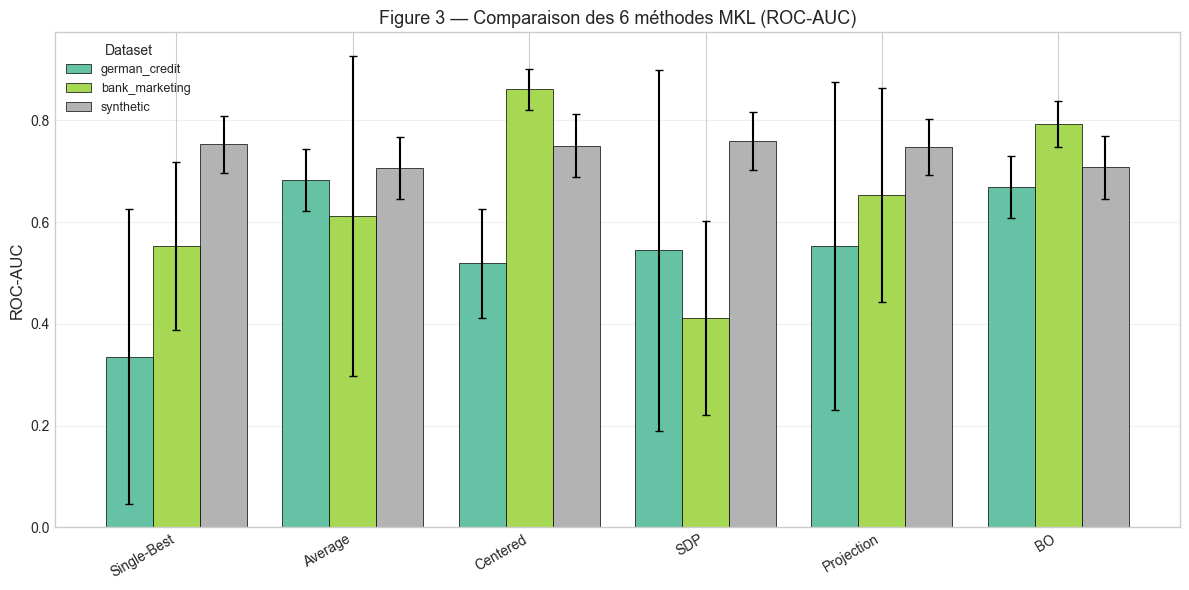

In [35]:
# ── FIGURE 3 : Barres groupées (6 méthodes × 3 datasets) ─────────────────────
plot_method_comparison_grouped(
    ALL_RESULTS,
    title='Figure 3 — Comparaison des 6 méthodes MKL (ROC-AUC)',
    save_path='../results/06/F03_method_comparison.png'
)

Computing BO multi-metrics (n_calls=20)...


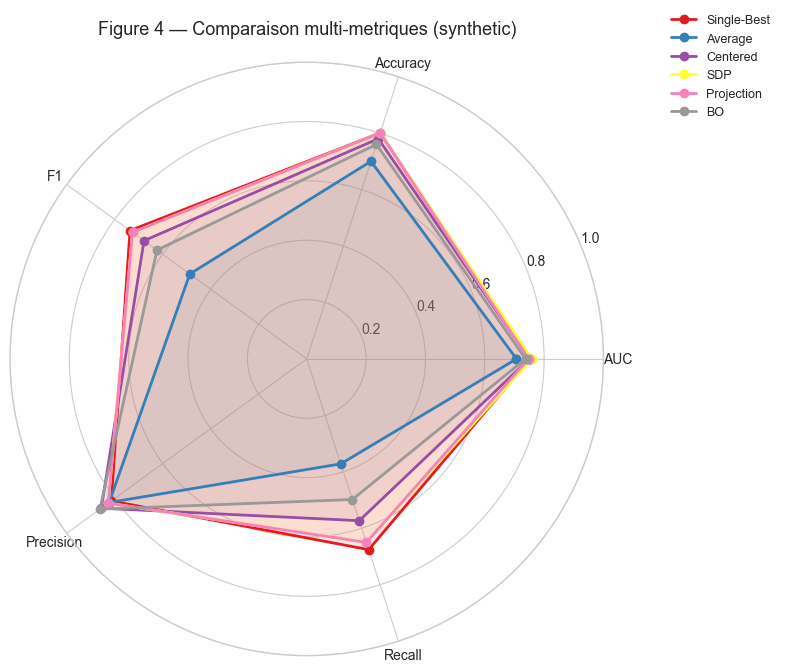

[65s] Figures 3-4 done


In [36]:
# ── FIGURE 4 : Radar chart multi-métriques ───────────────────────────────────
# Use the synthetic dataset and reuse cached results for simple methods
# For BO, run evaluate_method with the BO lambda (lighter: n_calls=20 for speed)
ds_name_radar = 'synthetic'
K_list = KERNELS[ds_name_radar]
y = DATASETS[ds_name_radar]['y']

radar_data = {}
for method_name, wfn in METHODS_SIMPLE.items():
    # Reuse if already computed with all_metrics
    res = ALL_RESULTS[ds_name_radar][method_name]
    if 'all_metrics' in res and res['all_metrics'] is not None:
        radar_data[method_name] = res['all_metrics']
    else:
        res2 = evaluate_method(K_list, y, wfn)
        radar_data[method_name] = res2['all_metrics']

# BO with lightweight settings for radar
print('Computing BO multi-metrics (n_calls=20)...')
bo_radar = evaluate_method(K_list, y,
    lambda K_tr, y_tr: BayesianKernelOptimizer(n_calls=20, n_initial_points=10,
                                                cv_folds=3, random_state=SEED).optimize(K_tr, y_tr)[0])
radar_data['BO'] = bo_radar['all_metrics']

# Build display dict
radar_display = {}
for method, metrics in radar_data.items():
    radar_display[method] = {
        'AUC': metrics['auc'], 'Accuracy': metrics['acc'],
        'F1': metrics['f1'], 'Precision': metrics['prec'], 'Recall': metrics['recall']
    }

plot_radar_chart(
    radar_display,
    title=f'Figure 4 — Comparaison multi-metriques ({ds_name_radar})',
    save_path='../results/06/F04_radar_chart.png'
)
print(f'[{time.time()-T_START:.0f}s] Figures 3-4 done')

## §4 — Deep Dive Bayesian Optimization

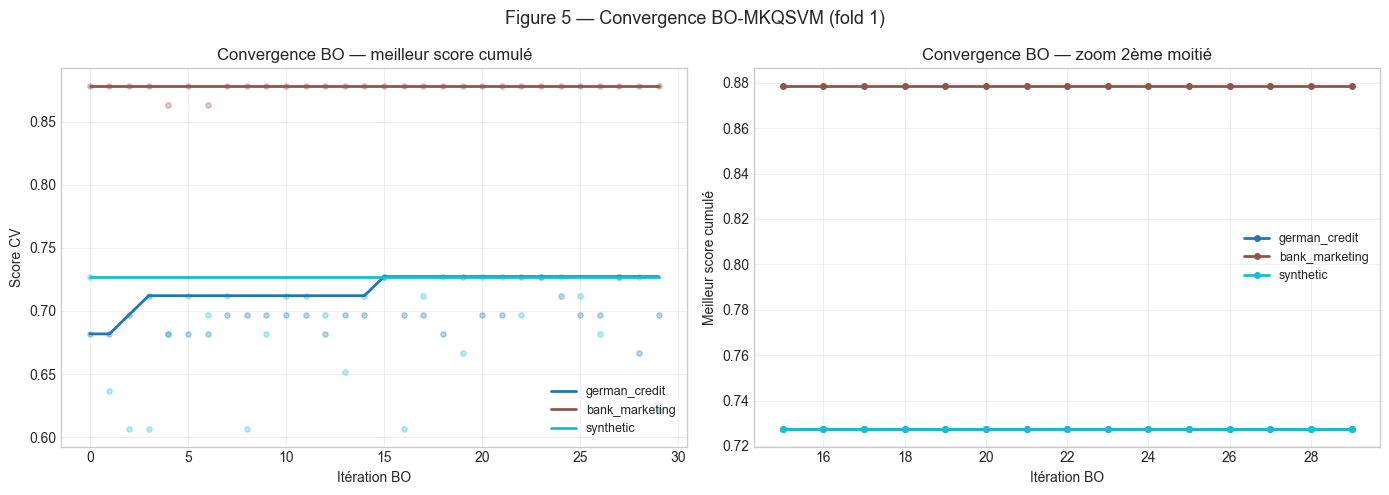

[66s] Figure 5 done


In [37]:
# ── FIGURE 5 : Convergence BO par dataset ─────────────────────────────────────
conv_histories = {ds: BO_HISTORIES[ds][0] for ds in BO_HISTORIES}

plot_bo_convergence(
    conv_histories,
    title='Figure 5 — Convergence BO-MKQSVM (fold 1)',
    save_path='../results/06/F05_bo_convergence.png'
)
print(f'[{time.time()-T_START:.0f}s] Figure 5 done')

  n_calls= 10: AUC=0.6923 (1.1s)
  n_calls= 20: AUC=0.7000 (3.0s)
  n_calls= 30: AUC=0.7154 (7.0s)
  n_calls= 50: AUC=0.6808 (31.3s)


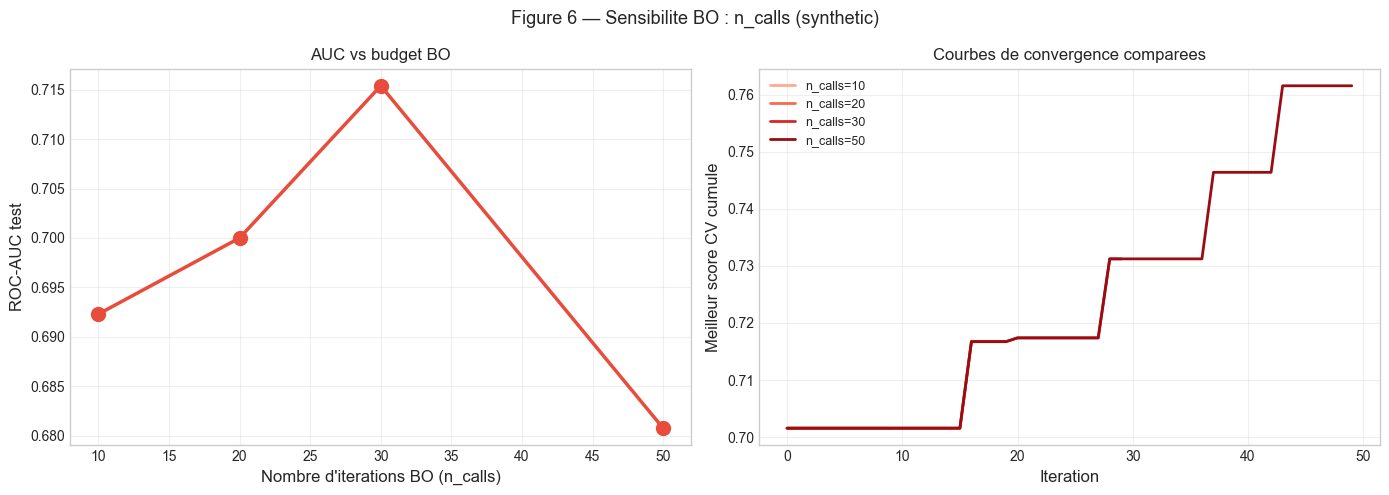

[109s] Figure 6 done


In [38]:
# ── FIGURE 6 : Sensibilité BO — n_calls vs AUC ───────────────────────────────
N_CALLS_RANGE = [10, 20, 30, 50]
sensitivity_results = {}

ds_name_sens = 'synthetic'
K_list = KERNELS[ds_name_sens]
y = DATASETS[ds_name_sens]['y']

# Single train/test split for speed
idx = np.arange(len(y))
idx_tr, idx_te = train_test_split(idx, test_size=0.33, random_state=SEED, stratify=y)
y_tr, y_te = y[idx_tr], y[idx_te]
K_tr = [K[np.ix_(idx_tr, idx_tr)] for K in K_list]
K_te = [K[np.ix_(idx_te, idx_tr)] for K in K_list]

for nc in N_CALLS_RANGE:
    t0 = time.time()
    bo = BayesianKernelOptimizer(n_calls=nc, n_initial_points=min(10, nc//2),
                                 cv_folds=3, random_state=SEED)
    w, C = bo.optimize(K_tr, y_tr, scoring='accuracy')
    Kc_tr = sum(wi * K for wi, K in zip(w, K_tr))
    Kc_te = sum(wi * K for wi, K in zip(w, K_te))
    ev = np.linalg.eigvalsh(Kc_tr)
    if ev.min() < 0:
        Kc_tr += (abs(ev.min()) + 1e-10) * np.eye(Kc_tr.shape[0])
    svm = SVC(kernel='precomputed', C=C, probability=True)
    svm.fit(Kc_tr, y_tr)
    auc = roc_auc_score(y_te, svm.predict_proba(Kc_te)[:, 1])
    sensitivity_results[nc] = {'auc': auc,
                                'best_score': bo.get_convergence_info()['best_score'],
                                'history': bo.get_convergence_history()}
    print(f'  n_calls={nc:3d}: AUC={auc:.4f} ({time.time()-t0:.1f}s)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ncs = sorted(sensitivity_results.keys())
aucs = [sensitivity_results[nc]['auc'] for nc in ncs]
ax.plot(ncs, aucs, 'o-', color='#e74c3c', linewidth=2.5, markersize=10)
ax.set_xlabel('Nombre d\'iterations BO (n_calls)', fontsize=12)
ax.set_ylabel('ROC-AUC test', fontsize=12)
ax.set_title('AUC vs budget BO')
ax.grid(True, alpha=0.3)

ax = axes[1]
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(ncs)))
for nc, c in zip(ncs, colors):
    h = sensitivity_results[nc]['history']
    ax.plot(h['best_so_far'], '-', color=c, linewidth=2, label=f'n_calls={nc}')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Meilleur score CV cumule', fontsize=12)
ax.set_title('Courbes de convergence comparees')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Figure 6 — Sensibilite BO : n_calls ({ds_name_sens})', fontsize=13)
plt.tight_layout()
plt.savefig('../results/06/F06_bo_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[{time.time()-T_START:.0f}s] Figure 6 done')

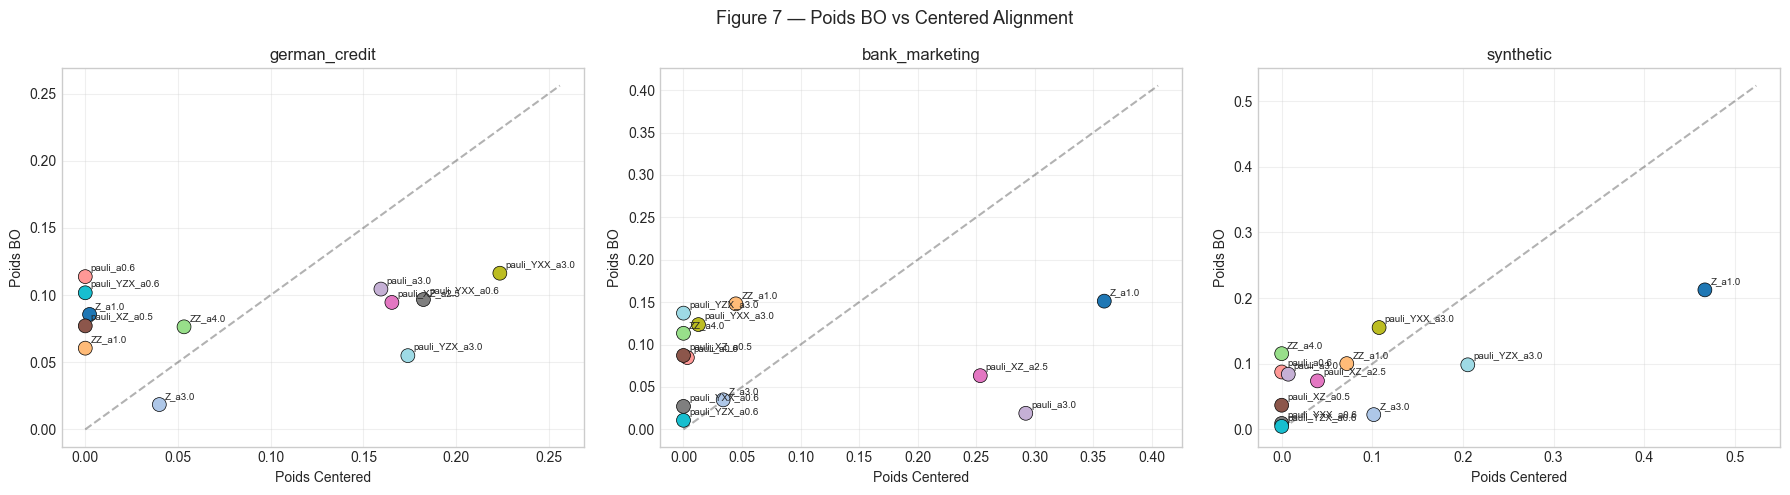

[109s] Figure 7 done


In [39]:
# ── FIGURE 7 : Poids BO vs Centered (scatter) ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, ds_name in zip(axes, DATASETS):
    w_bo = ALL_RESULTS[ds_name]['BO']['mean_weights']
    w_ca = ALL_RESULTS[ds_name]['Centered']['mean_weights']
    ax.scatter(w_ca, w_bo, c=range(len(KNAMES)), cmap='tab20', s=100,
               edgecolors='black', linewidth=0.5, zorder=3)
    for i, name in enumerate(KNAMES):
        ax.annotate(name, (w_ca[i], w_bo[i]),
                    textcoords='offset points', xytext=(4, 4), fontsize=7)
    lim = max(max(w_bo), max(w_ca)) * 1.1 + 0.01
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='y=x')
    ax.set_xlabel('Poids Centered', fontsize=10)
    ax.set_ylabel('Poids BO', fontsize=10)
    ax.set_title(ds_name)
    ax.grid(True, alpha=0.3)

plt.suptitle('Figure 7 — Poids BO vs Centered Alignment', fontsize=13)
plt.tight_layout()
plt.savefig('../results/06/F07_bo_vs_centered_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[{time.time()-T_START:.0f}s] Figure 7 done')

## §5 — Scaling Study : Performance vs n_qubits


n_qubits = 2
    fold 1/3: AUC=0.3214
    fold 2/3: AUC=0.4154
    fold 3/3: AUC=0.5231
  BO             : 0.4200 (9s)
  Centered       : 0.4004 (0s)
  Single-Best    : 0.5071 (0s)
  [9s for q=2]

n_qubits = 4
    fold 1/3: AUC=0.6821
    fold 2/3: AUC=0.6769
    fold 3/3: AUC=0.3500
  BO             : 0.5697 (9s)
  Centered       : 0.7429 (0s)
  Single-Best    : 0.7156 (0s)
  [9s for q=4]

n_qubits = 6
    fold 1/3: AUC=0.6500
    fold 2/3: AUC=0.7731
    fold 3/3: AUC=0.7269
  BO             : 0.7167 (9s)
  Centered       : 0.7500 (0s)
  Single-Best    : 0.7526 (0s)
  [9s for q=6]

n_qubits = 8
    fold 1/3: AUC=0.7179
    fold 2/3: AUC=0.8308
    fold 3/3: AUC=0.8327
  BO             : 0.7938 (9s)
  Centered       : 0.8261 (0s)
  Single-Best    : 0.8299 (0s)
  [9s for q=8]


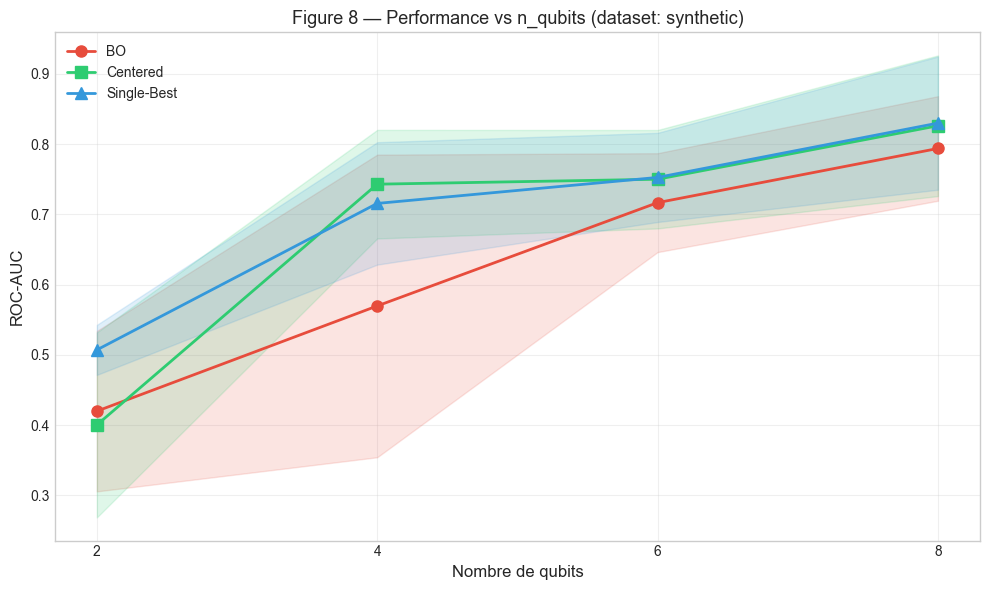


[145s] Figure 8 done


In [40]:
# ── FIGURE 8 : Scaling n_qubits avec CI95 ────────────────────────────────────
QUBIT_RANGE = [2, 4, 6, 8]
SCALING_METHODS = ['BO', 'Centered', 'Single-Best']
scaling_results = {m: {} for m in SCALING_METHODS}

ds_name_scale = 'synthetic'
X_raw = DATASETS[ds_name_scale]['X_raw']
y = DATASETS[ds_name_scale]['y']

for nq in QUBIT_RANGE:
    print(f'\nn_qubits = {nq}')
    t_nq = time.time()
    reducer = FeatureReducer(n_components=nq)
    scaler  = QuantumScaler(feature_range=(0, 2))
    X_proc = scaler.fit_transform(reducer.fit_transform(X_raw))

    # Build kernels (standard library)
    fm_lib_nq = get_feature_map_library(nq)
    knames_nq = list(fm_lib_nq.keys())
    qk_list = [build_quantum_kernel(fm, kernel_type='fidelity') for fm in fm_lib_nq.values()]
    K_list = compute_kernel_matrix_parallel(
        qk_list, X_proc,
        kernel_names=[f'scale_{ds_name_scale}_{nq}q_{n}' for n in knames_nq],
        n_jobs=-1
    )

    for method in SCALING_METHODS:
        t0 = time.time()
        if method == 'BO':
            bo_res = evaluate_bo(K_list, y, n_folds=N_CV, n_calls=20, seed=SEED)
            scaling_results[method][nq] = {
                'mean': bo_res['mean'], 'std': bo_res['std'], 'scores': bo_res['scores']
            }
        elif method == 'Centered':
            res = evaluate_method(K_list, y, weight_fn_centered)
            scaling_results[method][nq] = res
        elif method == 'Single-Best':
            res = evaluate_method(K_list, y, weight_fn_single_best)
            scaling_results[method][nq] = res
        print(f'  {method:15s}: {scaling_results[method][nq]["mean"]:.4f} ({time.time()-t0:.0f}s)')

    print(f'  [{time.time()-t_nq:.0f}s for q={nq}]')

plot_scaling_curve(
    scaling_results,
    title=f'Figure 8 — Performance vs n_qubits (dataset: {ds_name_scale})',
    save_path='../results/06/F08_scaling_qubits.png'
)
print(f'\n[{time.time()-T_START:.0f}s] Figure 8 done')

  q=2: done (cached)
  q=4: done (cached)
  q=6: done (cached)
  q=8: done (cached)


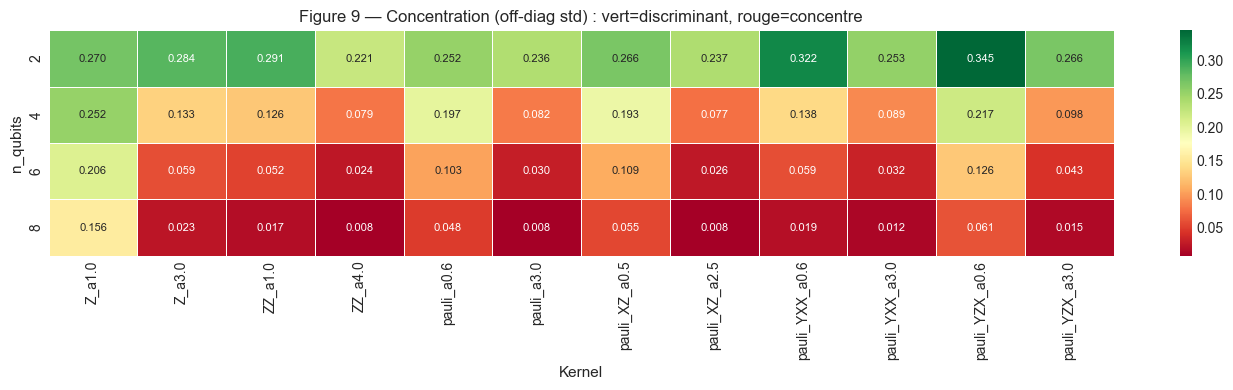

[146s] Figure 9 done


In [41]:
# ── FIGURE 9 : Heatmap concentration (n_qubits x kernel) ─────────────────────
# Reuse kernels from scaling study where possible (same data, same cache keys)
conc_data = np.zeros((len(QUBIT_RANGE), len(KNAMES)))

for i, nq in enumerate(QUBIT_RANGE):
    reducer = FeatureReducer(n_components=nq)
    scaler  = QuantumScaler(feature_range=(0, 2))
    X_proc = scaler.fit_transform(reducer.fit_transform(X_raw))
    fm_lib_nq = get_feature_map_library(nq)
    knames_nq = list(fm_lib_nq.keys())
    qk_list = [build_quantum_kernel(fm) for fm in fm_lib_nq.values()]
    K_list = compute_kernel_matrix_parallel(
        qk_list, X_proc,
        kernel_names=[f'scale_{ds_name_scale}_{nq}q_{n}' for n in knames_nq],  # same keys -> cached!
        n_jobs=-1
    )
    for j, K in enumerate(K_list):
        stats = _kernel_off_diagonal_stats(K)
        conc_data[i, j] = stats['std']
    print(f'  q={nq}: done (cached)')

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(conc_data, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=KNAMES, yticklabels=[str(nq) for nq in QUBIT_RANGE],
            ax=ax, linewidths=0.5, annot_kws={'fontsize': 8})
ax.set_xlabel('Kernel', fontsize=11)
ax.set_ylabel('n_qubits', fontsize=11)
ax.set_title('Figure 9 — Concentration (off-diag std) : vert=discriminant, rouge=concentre', fontsize=12)
plt.tight_layout()
plt.savefig('../results/06/F09_concentration_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[{time.time()-T_START:.0f}s] Figure 9 done')

## §6 — Analyse des poids

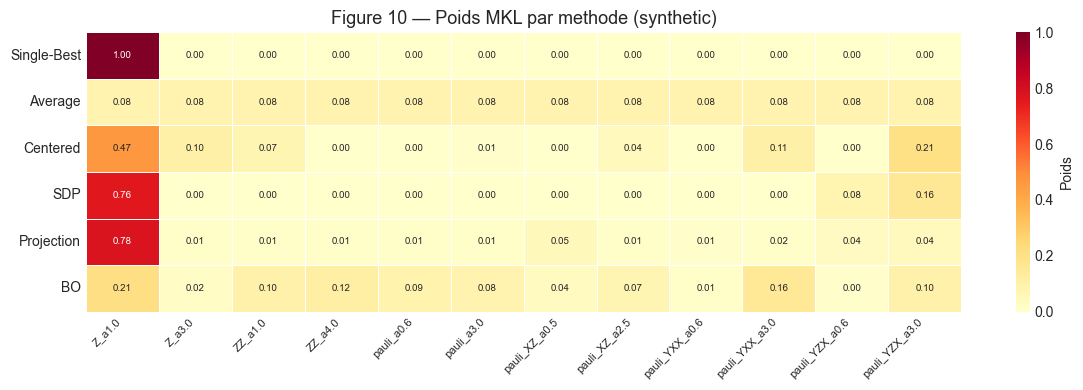

[146s] Figure 10 done


In [42]:
# ── FIGURE 10 : Heatmap poids (méthode × kernel) ─────────────────────────────
ds_name_weights = 'synthetic'
weights_dict = {}
for m in ALL_RESULTS[ds_name_weights]:
    w = ALL_RESULTS[ds_name_weights][m]['mean_weights']
    if w is not None:
        weights_dict[m] = w

plot_weight_heatmap(
    weights_dict, KNAMES,
    title=f'Figure 10 — Poids MKL par methode ({ds_name_weights})',
    save_path='../results/06/F10_weight_heatmap.png'
)
print(f'[{time.time()-T_START:.0f}s] Figure 10 done')

/var/folders/jc/c4xg98q12m1_hbcxk07rjkmm0000gn/T/ipykernel_4367/74241577.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)


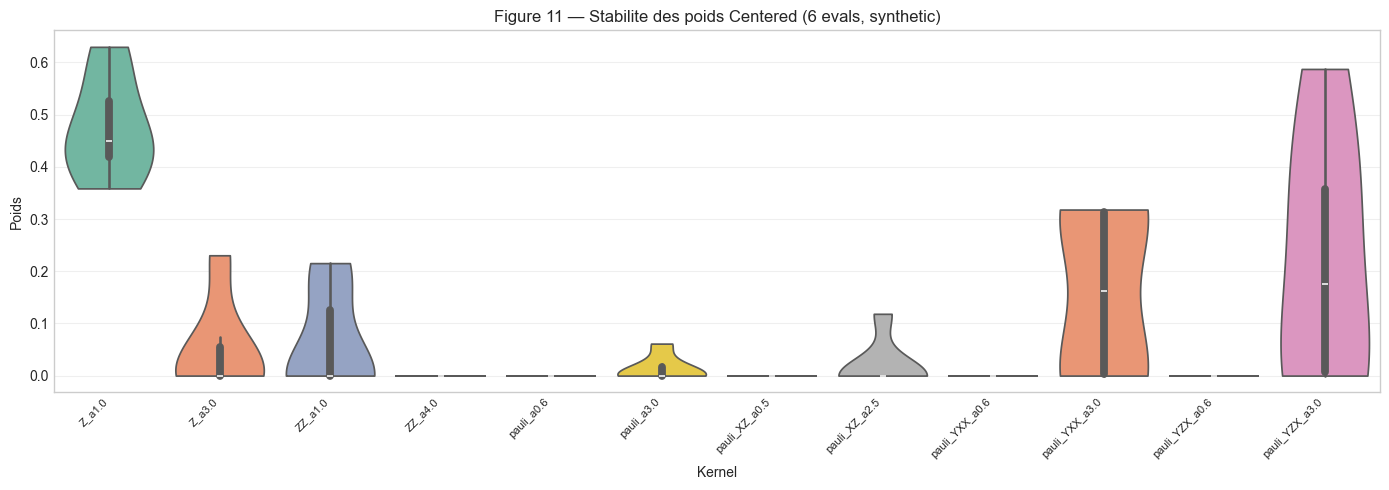

In [43]:
# ── FIGURE 11 : Violin plots stabilité des poids (multi-fold) ────────────────
from src.evaluation.ablation import weight_analysis

ds_name_weights = 'synthetic'
_, W_matrix = weight_analysis(
    KERNELS[ds_name_weights], DATASETS[ds_name_weights]['y'],
    weight_fn=weight_fn_centered,
    kernel_names=KNAMES,
    n_folds=3, n_rounds=2, random_state=SEED  # 2×3 = 6 evals (fast)
)

fig, ax = plt.subplots(figsize=(14, 5))
df_w = pd.DataFrame(W_matrix, columns=KNAMES)
df_melt = df_w.melt(var_name='Kernel', value_name='Poids')
sns.violinplot(data=df_melt, x='Kernel', y='Poids', ax=ax,
               palette='Set2', inner='box', cut=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_title(f'Figure 11 — Stabilite des poids Centered (6 evals, {ds_name_weights})', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/06/F11_weight_violin.png', dpi=150, bbox_inches='tight')
plt.show()

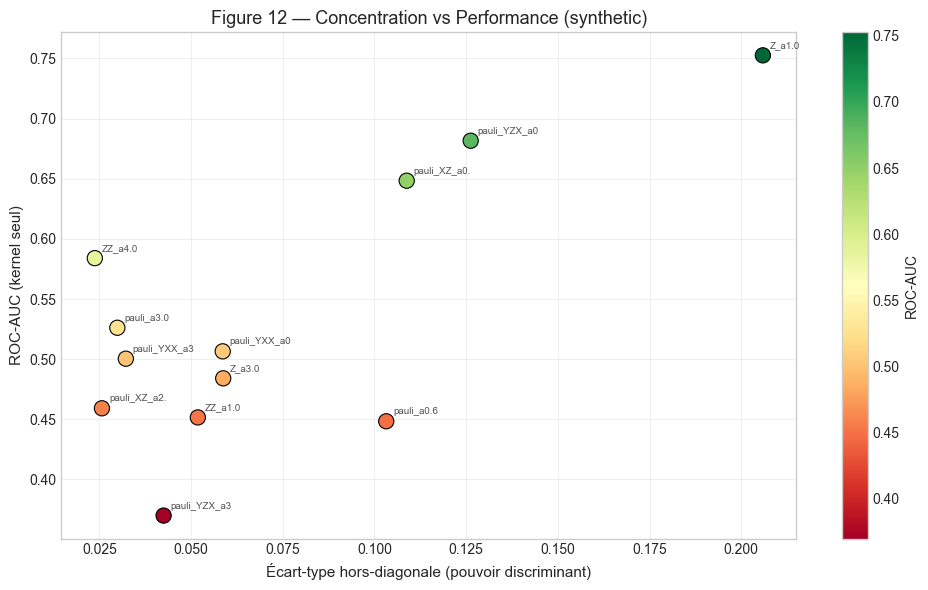

[147s] Figure 12 done


In [44]:
# ── FIGURE 12 : Concentration vs performance individuelle (scatter) ───────────
ds_name_conc = 'synthetic'
K_list_conc = KERNELS[ds_name_conc]
y_conc = DATASETS[ds_name_conc]['y']

single_aucs = []
stats_list = []
for K in K_list_conc:
    stats_list.append(_kernel_off_diagonal_stats(K))
    skf = StratifiedKFold(n_splits=N_CV, shuffle=True, random_state=SEED)
    aucs = []
    for idx_tr, idx_te in skf.split(np.zeros(len(y_conc)), y_conc):
        K_tr = K[np.ix_(idx_tr, idx_tr)]
        K_te = K[np.ix_(idx_te, idx_tr)]
        ev = np.linalg.eigvalsh(K_tr)
        if ev.min() < 0:
            K_tr = K_tr + (abs(ev.min()) + 1e-10) * np.eye(K_tr.shape[0])
        svm = SVC(kernel='precomputed', C=1.0, probability=True)
        svm.fit(K_tr, y_conc[idx_tr])
        aucs.append(roc_auc_score(y_conc[idx_te], svm.predict_proba(K_te)[:, 1]))
    single_aucs.append(np.mean(aucs))

plot_concentration_scatter(
    stats_list, single_aucs, KNAMES,
    title=f'Figure 12 — Concentration vs Performance ({ds_name_conc})',
    save_path='../results/06/F12_concentration_vs_perf.png'
)
print(f'[{time.time()-T_START:.0f}s] Figure 12 done')

## §7 — Fidelity vs Projected Kernel

synthetic — fidelity...
  AUC = 0.7486 +/- 0.0413 (0.0s)
synthetic — projected...
  AUC = 0.7312 +/- 0.0561 (0.0s)


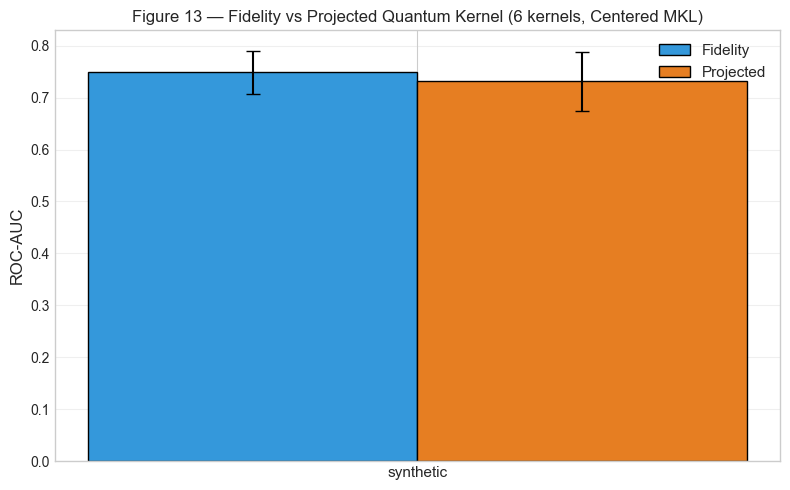

[147s] Figure 13 done


In [45]:
# ── FIGURE 13 : Fidelity vs Projected (paired bar) ───────────────────────────
# Projected kernel is MUCH slower (computes 1-RDMs). Use 6 kernels on 1 dataset.
PROJ_KERNELS = ['Z_a1.0', 'ZZ_a1.0', 'pauli_a0.6', 'pauli_XZ_a0.5', 'pauli_YXX_a0.6', 'pauli_YZX_a0.6']
PROJ_DS = ['synthetic']  # Single dataset for speed

fid_vs_proj = {}
for ds_name in PROJ_DS:
    X_proc = DATASETS[ds_name]['X']
    y = DATASETS[ds_name]['y']
    fid_vs_proj[ds_name] = {}

    for ktype in ['fidelity', 'projected']:
        print(f'{ds_name} — {ktype}...')
        t0 = time.time()
        # Build only the 6 selected kernels
        fm_subset = {k: fm_lib[k] for k in PROJ_KERNELS if k in fm_lib}
        knames_sub = list(fm_subset.keys())
        qk_list = [build_quantum_kernel(fm, kernel_type=ktype, gamma=1.0) for fm in fm_subset.values()]
        K_list = compute_kernel_matrix_parallel(
            qk_list, X_proc,
            kernel_names=[f'{ds_name}_{ktype}_{n}' for n in knames_sub],
            n_jobs=-1
        )
        res = evaluate_method(K_list, y, weight_fn_centered)
        fid_vs_proj[ds_name][ktype] = res
        print(f'  AUC = {res["mean"]:.4f} +/- {res["std"]:.4f} ({time.time()-t0:.1f}s)')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ds_names = list(fid_vs_proj.keys())
x = np.arange(len(ds_names))
w = 0.35
fid_vals = [fid_vs_proj[d]['fidelity']['mean'] for d in ds_names]
fid_errs = [fid_vs_proj[d]['fidelity']['std'] for d in ds_names]
proj_vals = [fid_vs_proj[d]['projected']['mean'] for d in ds_names]
proj_errs = [fid_vs_proj[d]['projected']['std'] for d in ds_names]

ax.bar(x - w/2, fid_vals, w, yerr=fid_errs, label='Fidelity', color='#3498db',
       edgecolor='black', capsize=5)
ax.bar(x + w/2, proj_vals, w, yerr=proj_errs, label='Projected', color='#e67e22',
       edgecolor='black', capsize=5)
ax.set_xticks(x)
ax.set_xticklabels(ds_names, fontsize=11)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title(f'Figure 13 — Fidelity vs Projected Quantum Kernel (6 kernels, Centered MKL)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/06/F13_fidelity_vs_projected.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[{time.time()-T_START:.0f}s] Figure 13 done')

## §7b — Tests statistiques (Wilcoxon) et Baseline classique

**Objectif** : Déterminer si les différences observées entre méthodes sont statistiquement significatives, et comparer avec des baselines classiques (SVM RBF, MKL classique).

- **Test de Wilcoxon** : test non-paramétrique sur scores appariés (même folds)
- **Cohen's d** : taille d'effet (négligeable < 0.2 < petit < 0.5 < moyen < 0.8 < grand)
- **Baselines classiques** : SVM RBF (single kernel), MKL avec kernels RBF à gammas variés

Running 10 random splits for statistical tests...

Running BO for statistical test...
  split 1/10: AUC=0.6538
  split 2/10: AUC=0.6115
  split 3/10: AUC=0.6269
  split 4/10: AUC=0.7192
  split 5/10: AUC=0.8654
  split 6/10: AUC=0.6769
  split 7/10: AUC=0.6808
  split 8/10: AUC=0.6538
  split 9/10: AUC=0.5615
  split 10/10: AUC=0.6731

Method              Mean      Std
-----------------------------------
Single-Best       0.7400   0.0774
Average           0.6346   0.1521
Centered          0.7362   0.0747
SDP               0.7412   0.0744
Projection        0.7437   0.0793
BO                0.6723   0.0805


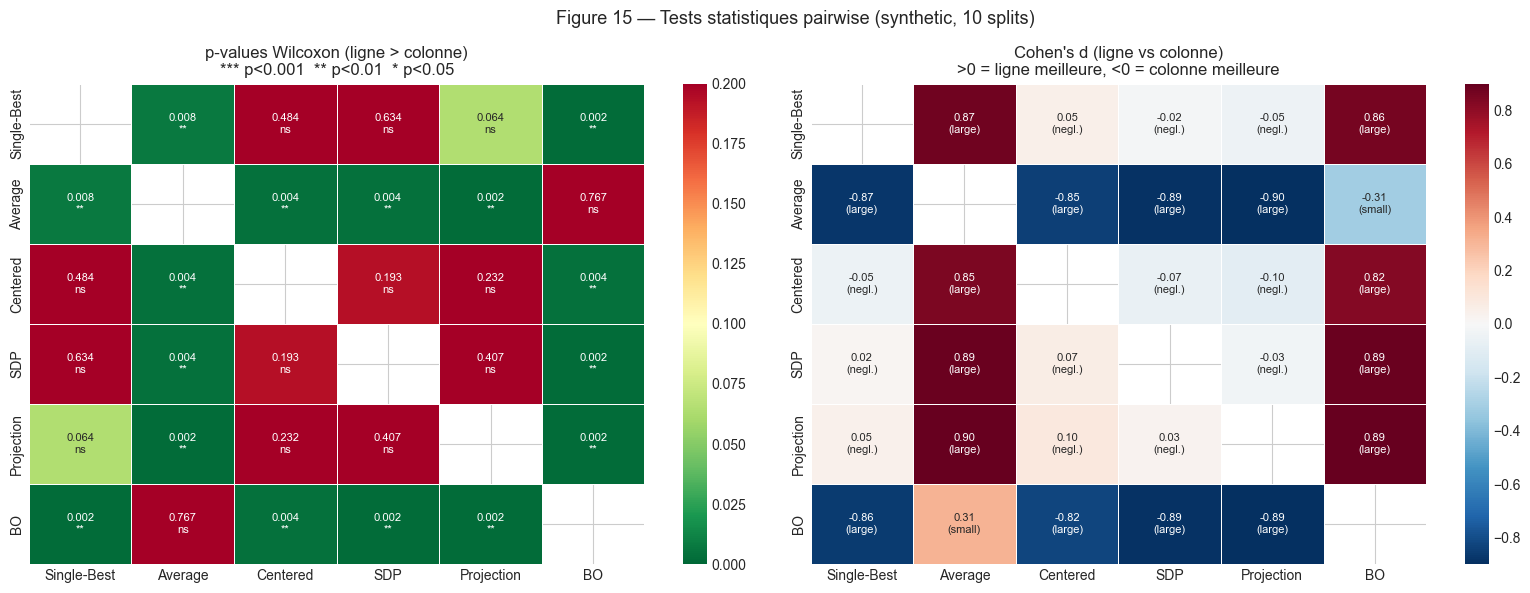


Differences significatives (p < 0.05) :
  Single-Best vs Average: p=0.0077, d=0.87
  Single-Best vs BO: p=0.0020, d=0.86
  Average vs Single-Best: p=0.0077, d=-0.87
  Average vs Centered: p=0.0039, d=-0.85
  Average vs SDP: p=0.0039, d=-0.89
  Average vs Projection: p=0.0020, d=-0.90
  Centered vs Average: p=0.0039, d=0.85
  Centered vs BO: p=0.0039, d=0.82
  SDP vs Average: p=0.0039, d=0.89
  SDP vs BO: p=0.0020, d=0.89
  Projection vs Average: p=0.0020, d=0.90
  Projection vs BO: p=0.0020, d=0.89
  BO vs Single-Best: p=0.0020, d=-0.86
  BO vs Centered: p=0.0039, d=-0.82
  BO vs SDP: p=0.0020, d=-0.89
  BO vs Projection: p=0.0020, d=-0.89

[175s] Figure 15 done


In [46]:
# ── FIGURE 15 : Tests statistiques pairwise (Wilcoxon + Cohen's d) ───────────
from src.evaluation.statistical_analysis import (
    multi_run_evaluation, pairwise_wilcoxon, cohens_d
)
from src.evaluation.visualization import plot_pairwise_significance

# Multi-run evaluation: 10 random splits, same methods
# Use precomputed kernel matrices for speed
N_STAT_RUNS = 10
print(f'Running {N_STAT_RUNS} random splits for statistical tests...\n')

STAT_METHODS = {
    'Single-Best': weight_fn_single_best,
    'Average':     weight_fn_average,
    'Centered':    weight_fn_centered,
    'SDP':         weight_fn_sdp,
    'Projection':  weight_fn_projection,
}

# Evaluate on synthetic dataset
ds_stat = 'synthetic'
stat_results = multi_run_evaluation(
    KERNELS[ds_stat], DATASETS[ds_stat]['y'],
    STAT_METHODS,
    n_runs=N_STAT_RUNS,
    test_size=0.33,
    scoring='roc_auc',
)

# Add BO results (slower — run separately with fewer calls)
print('Running BO for statistical test...')
bo_stat_scores = []
for seed in range(N_STAT_RUNS):
    idx = np.arange(len(DATASETS[ds_stat]['y']))
    idx_tr, idx_te = train_test_split(
        idx, test_size=0.33, random_state=seed,
        stratify=DATASETS[ds_stat]['y']
    )
    y_tr = DATASETS[ds_stat]['y'][idx_tr]
    y_te = DATASETS[ds_stat]['y'][idx_te]
    K_tr = [K[np.ix_(idx_tr, idx_tr)] for K in KERNELS[ds_stat]]
    K_te = [K[np.ix_(idx_te, idx_tr)] for K in KERNELS[ds_stat]]

    bo = BayesianKernelOptimizer(n_calls=20, n_initial_points=10,
                                 cv_folds=3, random_state=seed)
    w, C = bo.optimize(K_tr, y_tr, scoring='accuracy')
    Kc_tr = sum(wi * K for wi, K in zip(w, K_tr))
    Kc_te = sum(wi * K for wi, K in zip(w, K_te))
    ev = np.linalg.eigvalsh(Kc_tr)
    if ev.min() < 0:
        Kc_tr += (abs(ev.min()) + 1e-10) * np.eye(Kc_tr.shape[0])
    svm = SVC(kernel='precomputed', C=C, probability=True)
    svm.fit(Kc_tr, y_tr)
    bo_stat_scores.append(roc_auc_score(y_te, svm.predict_proba(Kc_te)[:, 1]))
    print(f'  split {seed+1}/{N_STAT_RUNS}: AUC={bo_stat_scores[-1]:.4f}')
stat_results['BO'] = bo_stat_scores

# Print summary
print(f'\n{"Method":15s} {"Mean":>8s} {"Std":>8s}')
print('-' * 35)
for name, scores in stat_results.items():
    print(f'{name:15s} {np.mean(scores):8.4f} {np.std(scores, ddof=1):8.4f}')

# Pairwise Wilcoxon tests (two-sided)
pvals = pairwise_wilcoxon(stat_results, alternative='two-sided')

# Cohen's d effect sizes
method_names = list(stat_results.keys())
effect_sizes = {a: {} for a in method_names}
for a in method_names:
    for b in method_names:
        effect_sizes[a][b] = cohens_d(stat_results[a], stat_results[b])

# Plot
plot_pairwise_significance(
    pvals, effect_sizes, method_names,
    title=f'Figure 15 — Tests statistiques pairwise ({ds_stat}, {N_STAT_RUNS} splits)',
    save_path='../results/06/F15_wilcoxon_tests.png'
)

# Print significant differences
print('\nDifferences significatives (p < 0.05) :')
for a in method_names:
    for b in method_names:
        if a != b and pvals[a][b] < 0.05:
            d = effect_sizes[a][b]
            print(f'  {a} vs {b}: p={pvals[a][b]:.4f}, d={d:.2f}')

print(f'\n[{time.time()-T_START:.0f}s] Figure 15 done')


german_credit: computing classical baselines...
  RBF (g=10.0)        : AUC = 0.5540 +/- 0.2416
  MKL-RBF (CA)        : AUC = 0.7402 +/- 0.0454
  Linear SVM          : AUC = 0.5685 +/- 0.0932
  (0.1s)

bank_marketing: computing classical baselines...
  RBF (g=0.1)         : AUC = 0.5740 +/- 0.4686
  MKL-RBF (CA)        : AUC = 0.8620 +/- 0.1036
  Linear SVM          : AUC = 0.8899 +/- 0.0825
  (0.1s)

synthetic: computing classical baselines...
  RBF (g=0.1)         : AUC = 0.7639 +/- 0.0493
  MKL-RBF (CA)        : AUC = 0.5562 +/- 0.3097
  Linear SVM          : AUC = 0.7396 +/- 0.0287
  (0.1s)


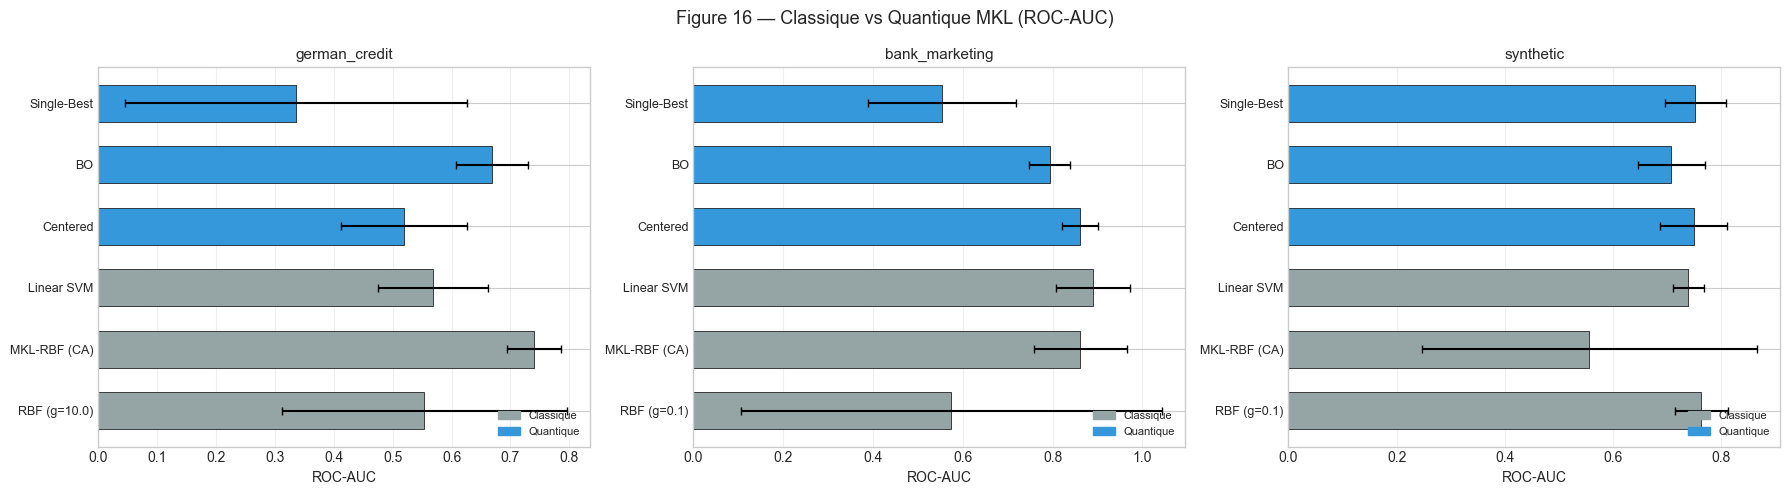


Dataset              | Best Classical            | Best Quantum              |    Delta
-------------------------------------------------------------------------------------
german_credit        | MKL-RBF (CA)    0.7402 | Average         0.6830 | -0.0572
bank_marketing       | Linear SVM      0.8899 | Centered        0.8609 | -0.0290
synthetic            | RBF (g=0.1)     0.7639 | SDP             0.7588 | -0.0051

[175s] Figure 16 done


In [47]:
# ── FIGURE 16 : Baseline classique vs Quantique ─────────────────────────────
from sklearn.metrics.pairwise import rbf_kernel
from src.evaluation.visualization import plot_classical_vs_quantum

def evaluate_classical_rbf(X, y, gammas=[0.01, 0.1, 1.0, 10.0], n_folds=N_CV, C=1.0, seed=SEED):
    """Evaluate classical SVM with RBF kernel (best gamma) + MKL RBF."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    results = {}

    # ── 1) Single best RBF (grid search gamma) ──
    best_gamma_auc = -1
    best_gamma = gammas[0]
    for gamma in gammas:
        aucs = []
        for idx_tr, idx_te in skf.split(X, y):
            svm = SVC(kernel='rbf', C=C, gamma=gamma, probability=True)
            svm.fit(X[idx_tr], y[idx_tr])
            aucs.append(roc_auc_score(y[idx_te], svm.predict_proba(X[idx_te])[:, 1]))
        mean_auc = np.mean(aucs)
        if mean_auc > best_gamma_auc:
            best_gamma_auc = mean_auc
            best_gamma = gamma

    # Final CV with best gamma
    aucs = []
    for idx_tr, idx_te in skf.split(X, y):
        svm = SVC(kernel='rbf', C=C, gamma=best_gamma, probability=True)
        svm.fit(X[idx_tr], y[idx_tr])
        aucs.append(roc_auc_score(y[idx_te], svm.predict_proba(X[idx_te])[:, 1]))
    results[f'RBF (g={best_gamma})'] = {'mean': np.mean(aucs), 'std': np.std(aucs, ddof=1),
                                         'scores': aucs}

    # ── 2) Classical MKL: combine RBF kernels at different gammas ──
    K_rbf_list = [rbf_kernel(X, gamma=g) for g in gammas]

    # Centered alignment weights
    from src.mkl.alignment import centered_alignment
    Ky = np.outer(y, y).astype(float)
    ca_aucs = []
    for idx_tr, idx_te in skf.split(X, y):
        K_tr = [K[np.ix_(idx_tr, idx_tr)] for K in K_rbf_list]
        K_te = [K[np.ix_(idx_te, idx_tr)] for K in K_rbf_list]
        Ky_tr = np.outer(y[idx_tr], y[idx_tr]).astype(float)
        w = centered_alignment(K_tr, Ky_tr)
        w = np.array(w)
        if w.sum() > 0: w = w / w.sum()
        else: w = np.ones(len(K_rbf_list)) / len(K_rbf_list)
        Kc_tr = sum(wi * K for wi, K in zip(w, K_tr))
        Kc_te = sum(wi * K for wi, K in zip(w, K_te))
        ev = np.linalg.eigvalsh(Kc_tr)
        if ev.min() < 0:
            Kc_tr += (abs(ev.min()) + 1e-10) * np.eye(Kc_tr.shape[0])
        svm = SVC(kernel='precomputed', C=C, probability=True)
        svm.fit(Kc_tr, y[idx_tr])
        ca_aucs.append(roc_auc_score(y[idx_te], svm.predict_proba(Kc_te)[:, 1]))
    results['MKL-RBF (CA)'] = {'mean': np.mean(ca_aucs), 'std': np.std(ca_aucs, ddof=1),
                                'scores': ca_aucs}

    # ── 3) Linear SVM baseline ──
    from sklearn.svm import LinearSVC
    from sklearn.calibration import CalibratedClassifierCV
    lin_aucs = []
    for idx_tr, idx_te in skf.split(X, y):
        base_svm = LinearSVC(C=C, max_iter=5000, dual=True)
        svm = CalibratedClassifierCV(base_svm, cv=3)
        svm.fit(X[idx_tr], y[idx_tr])
        lin_aucs.append(roc_auc_score(y[idx_te], svm.predict_proba(X[idx_te])[:, 1]))
    results['Linear SVM'] = {'mean': np.mean(lin_aucs), 'std': np.std(lin_aucs, ddof=1),
                              'scores': lin_aucs}

    return results


# Run classical baselines on all datasets
CLASSICAL_RESULTS = {}
for ds_name, ds in DATASETS.items():
    print(f'\n{ds_name}: computing classical baselines...')
    t0 = time.time()
    CLASSICAL_RESULTS[ds_name] = evaluate_classical_rbf(ds['X'], ds['y'])
    for m, r in CLASSICAL_RESULTS[ds_name].items():
        print(f'  {m:20s}: AUC = {r["mean"]:.4f} +/- {r["std"]:.4f}')
    print(f'  ({time.time()-t0:.1f}s)')

# Build quantum results dict for comparison
QUANTUM_FOR_PLOT = {}
for ds_name in DATASETS:
    QUANTUM_FOR_PLOT[ds_name] = {m: ALL_RESULTS[ds_name][m]
                                  for m in ['Centered', 'BO', 'Single-Best']}

plot_classical_vs_quantum(
    CLASSICAL_RESULTS, QUANTUM_FOR_PLOT, list(DATASETS.keys()),
    title='Figure 16 — Classique vs Quantique MKL (ROC-AUC)',
    save_path='../results/06/F16_classical_vs_quantum.png'
)

# Summary table
print(f'\n{"Dataset":20s} | {"Best Classical":25s} | {"Best Quantum":25s} | {"Delta":>8s}')
print('-' * 85)
for ds_name in DATASETS:
    c_best_name = max(CLASSICAL_RESULTS[ds_name], key=lambda m: CLASSICAL_RESULTS[ds_name][m]['mean'])
    c_best = CLASSICAL_RESULTS[ds_name][c_best_name]['mean']
    q_best_name = max(ALL_RESULTS[ds_name], key=lambda m: ALL_RESULTS[ds_name][m]['mean'])
    q_best = ALL_RESULTS[ds_name][q_best_name]['mean']
    delta = q_best - c_best
    sign = '+' if delta > 0 else ''
    print(f'{ds_name:20s} | {c_best_name:15s} {c_best:.4f} | {q_best_name:15s} {q_best:.4f} | {sign}{delta:.4f}')

print(f'\n[{time.time()-T_START:.0f}s] Figure 16 done')

## §9 — Dataset quantiquement avantageux (Huang et al. 2021)

**Principe** : On genere un dataset dont les labels sont definis par une mesure quantique :
$$y = \text{sign}\left(\langle\psi(x)|O|\psi(x)\rangle\right)$$
avec $O$ un observable aleatoire et $|\psi(x)\rangle = U(x)|0\rangle$ le feature map quantique.

**Pourquoi c'est avantageux** : la frontiere de decision vit naturellement dans l'espace de Hilbert
du circuit. Le kernel quantique $K(x,x') = |\langle\psi(x)|\psi(x')\rangle|^2$ la capture directement,
tandis qu'un kernel RBF classique aurait besoin d'exponentiellement plus de features.

**Parametres cles** :
- `complexity` : rotation de l'observable (0=facile, 1=dur pour le classique)
- `reps` : profondeur du circuit (reps=2 crucial pour l'avantage)

Generating quantum-advantage dataset...
  Generated in 0.7s
  Shape: (100, 6), classes: [50 50]
  Observable: rotated_z, complexity: 0.5


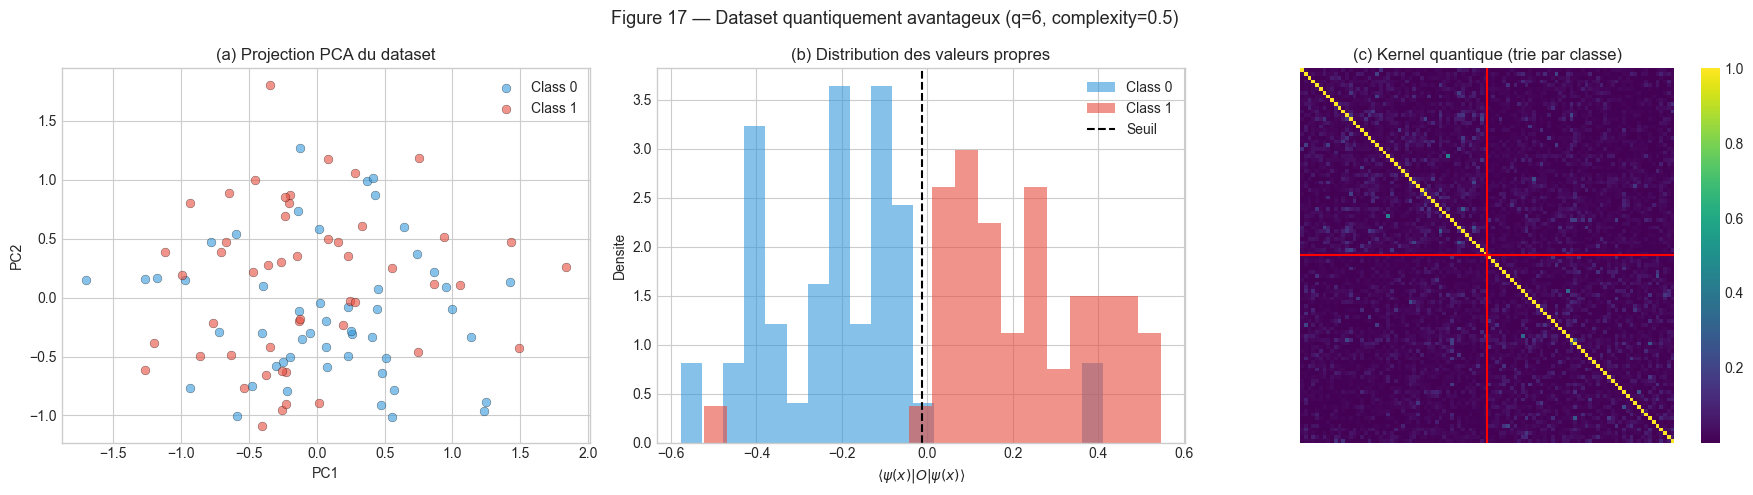

[177s] Figure 17 done


In [48]:
# ── FIGURE 17 : Quantum-advantage dataset — generation + visualisation ───────
from data.quantum_dataset import generate_quantum_advantage_dataset
from sklearn.decomposition import PCA

# Generate quantum-native dataset (reps=2 crucial for advantage)
QADV_PARAMS = dict(
    n_samples=N_SAMPLES, n_qubits=N_QUBITS, feature_map_name='ZZ',
    alpha=1.0, reps=2, complexity=0.5, noise=0.03, random_state=SEED
)

print('Generating quantum-advantage dataset...')
t0 = time.time()
X_qa, y_qa, meta_qa = generate_quantum_advantage_dataset(**QADV_PARAMS)
print(f'  Generated in {time.time()-t0:.1f}s')
print(f'  Shape: {X_qa.shape}, classes: {np.bincount(y_qa)}')
print(f'  Observable: {meta_qa["observable_type"]}, complexity: {meta_qa["complexity"]}')

# Visualization: PCA projection + expectation values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) PCA 2D projection colored by class
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_qa)
for c, label, color in [(0, 'Class 0', '#3498db'), (1, 'Class 1', '#e74c3c')]:
    mask = y_qa == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label,
                    alpha=0.6, s=40, edgecolors='black', linewidth=0.3)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title('(a) Projection PCA du dataset')
axes[0].legend()

# (b) Distribution of expectation values
exp_vals = meta_qa['expectation_values']
axes[1].hist(exp_vals[y_qa == 0], bins=20, alpha=0.6, color='#3498db', label='Class 0', density=True)
axes[1].hist(exp_vals[y_qa == 1], bins=20, alpha=0.6, color='#e74c3c', label='Class 1', density=True)
axes[1].axvline(meta_qa['threshold'], color='black', linestyle='--', label='Seuil')
axes[1].set_xlabel(r'$\langle\psi(x)|O|\psi(x)\rangle$')
axes[1].set_ylabel('Densite')
axes[1].set_title('(b) Distribution des valeurs propres')
axes[1].legend()

# (c) Quantum kernel heatmap (sorted by class)
order = np.argsort(y_qa)
fm_qa = build_feature_map('ZZ', N_QUBITS, alpha=1.0, reps=2)
qk_qa = build_quantum_kernel(fm_qa)
K_qa_single = compute_kernel_matrix(qk_qa, X_qa, cache_key=f'qadv_single_{N_QUBITS}q')
K_sorted = K_qa_single[np.ix_(order, order)]
sns.heatmap(K_sorted, cmap='viridis', ax=axes[2], cbar=True, square=True)
n0 = np.sum(y_qa == 0)
axes[2].axhline(n0, color='red', linewidth=1.5)
axes[2].axvline(n0, color='red', linewidth=1.5)
axes[2].set_title('(c) Kernel quantique (trie par classe)')
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.suptitle(f'Figure 17 — Dataset quantiquement avantageux (q={N_QUBITS}, complexity={QADV_PARAMS["complexity"]})',
             fontsize=13)
plt.tight_layout()
plt.savefig('../results/06/F17_quantum_advantage_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[{time.time()-T_START:.0f}s] Figure 17 done')

=== Quantum MKL sur quantum-advantage dataset ===

Quantum kernels: 12 matrices (0s)
  Q-Single-Best       : AUC = 0.4188 +/- 0.0188
  Q-Average           : AUC = 0.5651 +/- 0.0486
  Q-Centered          : AUC = 0.8176 +/- 0.0578
  Q-SDP               : AUC = 0.5076 +/- 0.0983
  Q-BO: running...
  Q-BO                : AUC = 0.5661 +/- 0.0445
  C-RBF               : AUC = 0.5573 (gamma=1.0)
  C-MKL-RBF           : AUC = 0.4883 +/- 0.0695
  C-Linear            : AUC = 0.5259


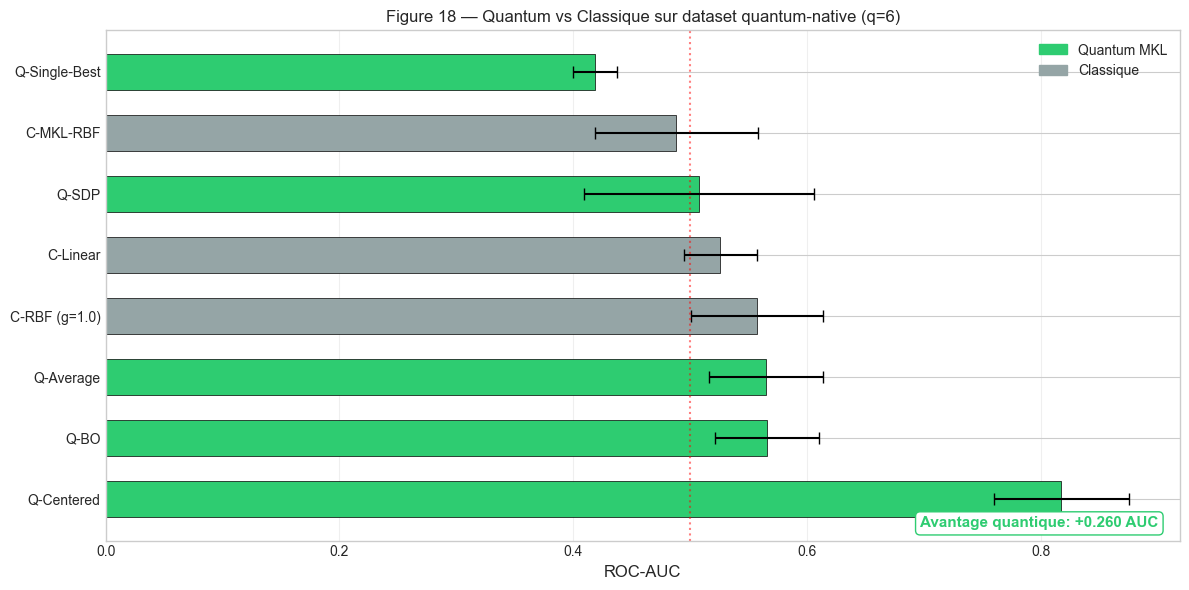


[186s] Figure 18 done


In [49]:
# ── FIGURE 18 : Quantum vs Classical sur dataset quantum-native ──────────────
from sklearn.metrics.pairwise import rbf_kernel

print('=== Quantum MKL sur quantum-advantage dataset ===\n')

# 1. Build quantum MKL kernels
t0 = time.time()
fm_lib_qa = get_feature_map_library(N_QUBITS)
KNAMES_QA = list(fm_lib_qa.keys())
qk_qa_list = [build_quantum_kernel(fm) for fm in fm_lib_qa.values()]
K_qa_list = compute_kernel_matrix_parallel(
    qk_qa_list, X_qa,
    kernel_names=[f'qadv_mkl_{N_QUBITS}q_{n}' for n in KNAMES_QA],
    n_jobs=-1
)
print(f'Quantum kernels: {len(K_qa_list)} matrices ({time.time()-t0:.0f}s)')

# 2. Classical RBF kernels
GAMMAS = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
K_rbf_qa = [rbf_kernel(X_qa, gamma=g) for g in GAMMAS]

# 3. Evaluate all methods
skf_qa = StratifiedKFold(n_splits=N_CV, shuffle=True, random_state=SEED)

def eval_on_qa(K_list, y, weight_fn, label=''):
    aucs = []
    for tr, te in skf_qa.split(np.zeros(len(y)), y):
        K_tr = [K[np.ix_(tr, tr)] for K in K_list]
        K_te = [K[np.ix_(te, tr)] for K in K_list]
        w = weight_fn(K_tr, y[tr])
        w = np.array(w)
        if w.sum() > 0: w /= w.sum()
        else: w = np.ones(len(K_list)) / len(K_list)
        Kc_tr = sum(wi*K for wi, K in zip(w, K_tr))
        Kc_te = sum(wi*K for wi, K in zip(w, K_te))
        ev = np.linalg.eigvalsh(Kc_tr)
        if ev.min() < 0: Kc_tr += (abs(ev.min())+1e-10)*np.eye(Kc_tr.shape[0])
        svm = SVC(kernel='precomputed', C=1.0, probability=True)
        svm.fit(Kc_tr, y[tr])
        aucs.append(roc_auc_score(y[te], svm.predict_proba(Kc_te)[:,1]))
    return {'mean': np.mean(aucs), 'std': np.std(aucs, ddof=1), 'scores': aucs}

QA_RESULTS = {}

# Quantum methods
for name, wfn in [('Q-Single-Best', weight_fn_single_best),
                   ('Q-Average', weight_fn_average),
                   ('Q-Centered', weight_fn_centered),
                   ('Q-SDP', weight_fn_sdp)]:
    r = eval_on_qa(K_qa_list, y_qa, wfn, name)
    QA_RESULTS[name] = r
    print(f'  {name:20s}: AUC = {r["mean"]:.4f} +/- {r["std"]:.4f}')

# Quantum BO
print('  Q-BO: running...')
bo_qa_aucs = []
for tr, te in skf_qa.split(np.zeros(len(y_qa)), y_qa):
    K_tr = [K[np.ix_(tr, tr)] for K in K_qa_list]
    K_te = [K[np.ix_(te, tr)] for K in K_qa_list]
    bo = BayesianKernelOptimizer(n_calls=20, n_initial_points=10, cv_folds=3, random_state=SEED)
    w, C = bo.optimize(K_tr, y_qa[tr], scoring='accuracy')
    Kc_tr = sum(wi*K for wi, K in zip(w, K_tr))
    Kc_te = sum(wi*K for wi, K in zip(w, K_te))
    ev = np.linalg.eigvalsh(Kc_tr)
    if ev.min() < 0: Kc_tr += (abs(ev.min())+1e-10)*np.eye(Kc_tr.shape[0])
    svm = SVC(kernel='precomputed', C=C, probability=True)
    svm.fit(Kc_tr, y_qa[tr])
    bo_qa_aucs.append(roc_auc_score(y_qa[te], svm.predict_proba(Kc_te)[:,1]))
QA_RESULTS['Q-BO'] = {'mean': np.mean(bo_qa_aucs), 'std': np.std(bo_qa_aucs, ddof=1), 'scores': bo_qa_aucs}
print(f'  {"Q-BO":20s}: AUC = {QA_RESULTS["Q-BO"]["mean"]:.4f} +/- {QA_RESULTS["Q-BO"]["std"]:.4f}')

# Classical methods
# Best single RBF
best_rbf_auc = 0
best_rbf_g = GAMMAS[0]
for g in GAMMAS:
    aucs_g = []
    for tr, te in skf_qa.split(np.zeros(len(y_qa)), y_qa):
        svm = SVC(kernel='rbf', C=1.0, gamma=g, probability=True)
        svm.fit(X_qa[tr], y_qa[tr])
        aucs_g.append(roc_auc_score(y_qa[te], svm.predict_proba(X_qa[te])[:,1]))
    if np.mean(aucs_g) > best_rbf_auc:
        best_rbf_auc = np.mean(aucs_g)
        best_rbf_g = g
        best_rbf_scores = aucs_g
QA_RESULTS[f'C-RBF (g={best_rbf_g})'] = {'mean': best_rbf_auc, 'std': np.std(best_rbf_scores, ddof=1), 'scores': best_rbf_scores}
print(f'  {"C-RBF":20s}: AUC = {best_rbf_auc:.4f} (gamma={best_rbf_g})')

# Classical MKL-RBF
r_cmkl = eval_on_qa(K_rbf_qa, y_qa, weight_fn_centered, 'C-MKL-RBF')
QA_RESULTS['C-MKL-RBF'] = r_cmkl
print(f'  {"C-MKL-RBF":20s}: AUC = {r_cmkl["mean"]:.4f} +/- {r_cmkl["std"]:.4f}')

# Linear SVM
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
lin_aucs = []
for tr, te in skf_qa.split(np.zeros(len(y_qa)), y_qa):
    base_svm = LinearSVC(C=1.0, max_iter=5000, dual=True)
    svm_cal = CalibratedClassifierCV(base_svm, cv=3)
    svm_cal.fit(X_qa[tr], y_qa[tr])
    lin_aucs.append(roc_auc_score(y_qa[te], svm_cal.predict_proba(X_qa[te])[:,1]))
QA_RESULTS['C-Linear'] = {'mean': np.mean(lin_aucs), 'std': np.std(lin_aucs, ddof=1), 'scores': lin_aucs}
print(f'  {"C-Linear":20s}: AUC = {np.mean(lin_aucs):.4f}')

# ── Plot F18 : Comparison bar chart ──
fig, ax = plt.subplots(figsize=(12, 6))
names_sorted = sorted(QA_RESULTS.keys(), key=lambda m: QA_RESULTS[m]['mean'], reverse=True)
means = [QA_RESULTS[m]['mean'] for m in names_sorted]
stds  = [QA_RESULTS[m]['std'] for m in names_sorted]
colors = ['#2ecc71' if m.startswith('Q-') else '#95a5a6' for m in names_sorted]

bars = ax.barh(range(len(names_sorted)), means, xerr=stds, color=colors,
               edgecolor='black', linewidth=0.5, capsize=4, height=0.6)
ax.set_yticks(range(len(names_sorted)))
ax.set_yticklabels(names_sorted, fontsize=10)
ax.set_xlabel('ROC-AUC', fontsize=12)
ax.axvline(0.5, color='red', linestyle=':', alpha=0.5, label='Random (0.5)')
ax.set_title(f'Figure 18 — Quantum vs Classique sur dataset quantum-native (q={N_QUBITS})', fontsize=12)
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#2ecc71', label='Quantum MKL'),
                   Patch(color='#95a5a6', label='Classique')], fontsize=10)

# Annotate delta
q_best = max((m for m in QA_RESULTS if m.startswith('Q-')), key=lambda m: QA_RESULTS[m]['mean'])
c_best = max((m for m in QA_RESULTS if m.startswith('C-')), key=lambda m: QA_RESULTS[m]['mean'])
delta = QA_RESULTS[q_best]['mean'] - QA_RESULTS[c_best]['mean']
ax.text(0.98, 0.02, f'Avantage quantique: +{delta:.3f} AUC',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=11, fontweight='bold', color='#2ecc71',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#2ecc71'))

plt.tight_layout()
plt.savefig('../results/06/F18_quantum_advantage_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n[{time.time()-T_START:.0f}s] Figure 18 done')


q=2: generating quantum-advantage dataset...
  Q-Centered: 0.8927
  Q-BO:       0.7953
  C-Best-RBF: 0.8492
  C-MKL-RBF:  0.8492
  [5s]

q=4: generating quantum-advantage dataset...
  Q-Centered: 0.7560
  Q-BO:       0.6762
  C-Best-RBF: 0.7391
  C-MKL-RBF:  0.4952
  [5s]

q=6: generating quantum-advantage dataset...
  Q-Centered: 0.8176
  Q-BO:       0.5032
  C-Best-RBF: 0.5573
  C-MKL-RBF:  0.4901
  [5s]

q=8: generating quantum-advantage dataset...
  Q-Centered: 0.5643
  Q-BO:       0.5987
  C-Best-RBF: 0.6005
  C-MKL-RBF:  0.5467
  [7s]


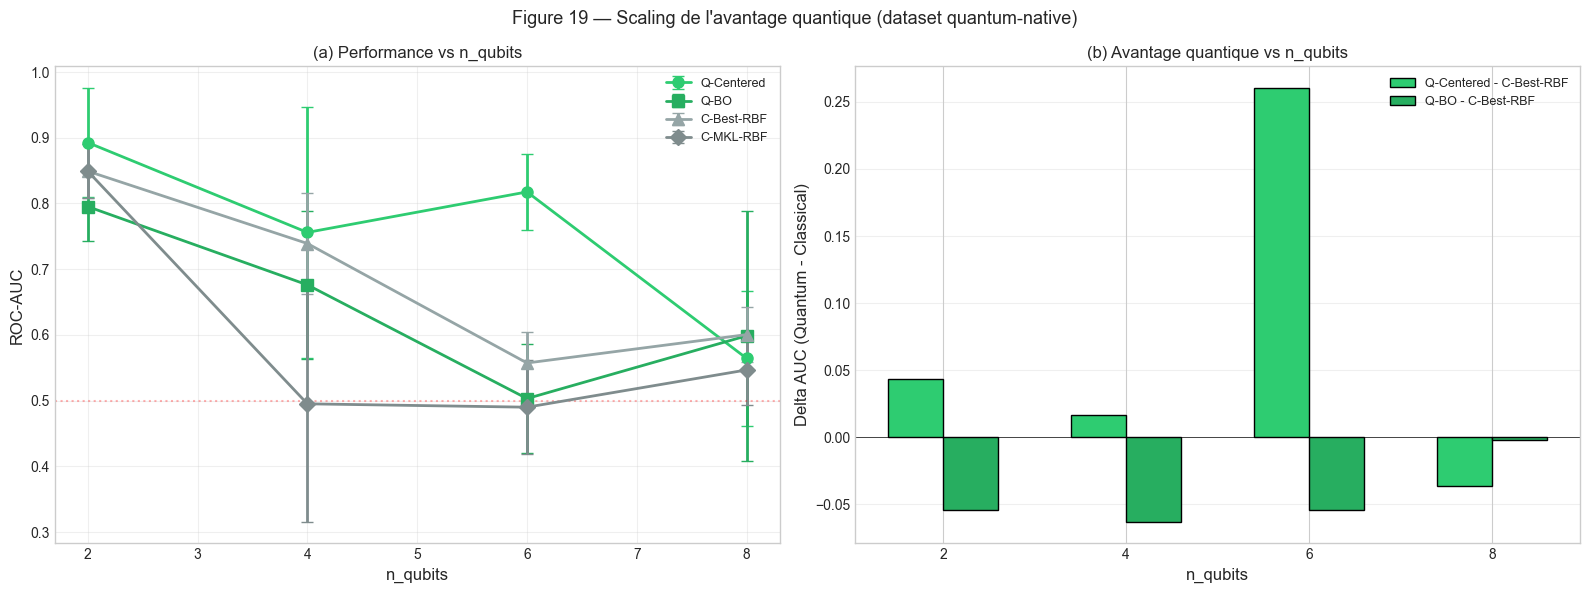


=== Avantage quantique par n_qubits ===
   q |   Q-Centered |   C-Best-RBF |    Delta
---------------------------------------------
   2 |       0.8927 |       0.8492 |  +0.0435
   4 |       0.7560 |       0.7391 |  +0.0169
   6 |       0.8176 |       0.5573 |  +0.2603
   8 |       0.5643 |       0.6005 |  -0.0362

[209s] Figure 19 done


In [50]:
# ── FIGURE 19 : Avantage quantique vs n_qubits ──────────────────────────────
# How does the quantum advantage scale with the number of qubits?
QA_QUBIT_RANGE = [2, 4, 6, 8]
qa_scaling = {'Q-Centered': {}, 'Q-BO': {}, 'C-Best-RBF': {}, 'C-MKL-RBF': {}}

for nq in QA_QUBIT_RANGE:
    print(f'\nq={nq}: generating quantum-advantage dataset...')
    t_nq = time.time()

    X_nq, y_nq, _ = generate_quantum_advantage_dataset(
        n_samples=N_SAMPLES, n_qubits=nq, feature_map_name='ZZ',
        alpha=1.0, reps=2, complexity=0.5, noise=0.03, random_state=SEED
    )

    # Quantum kernels
    fm_lib_nq = get_feature_map_library(nq)
    qk_list_nq = [build_quantum_kernel(fm) for fm in fm_lib_nq.values()]
    K_q_nq = compute_kernel_matrix_parallel(
        qk_list_nq, X_nq,
        kernel_names=[f'qadv_scale_{nq}q_{n}' for n in fm_lib_nq.keys()],
        n_jobs=-1
    )

    # Classical RBF kernels
    K_rbf_nq = [rbf_kernel(X_nq, gamma=g) for g in GAMMAS]

    skf_nq = StratifiedKFold(n_splits=N_CV, shuffle=True, random_state=SEED)

    # Q-Centered
    r = eval_on_qa(K_q_nq, y_nq, weight_fn_centered)
    qa_scaling['Q-Centered'][nq] = r
    print(f'  Q-Centered: {r["mean"]:.4f}')

    # Q-BO (lightweight)
    bo_aucs_nq = []
    for tr, te in skf_nq.split(np.zeros(len(y_nq)), y_nq):
        K_tr = [K[np.ix_(tr, tr)] for K in K_q_nq]
        K_te = [K[np.ix_(te, tr)] for K in K_q_nq]
        bo = BayesianKernelOptimizer(n_calls=15, n_initial_points=10, cv_folds=3, random_state=SEED)
        w, C = bo.optimize(K_tr, y_nq[tr])
        Kc_tr = sum(wi*K for wi, K in zip(w, K_tr))
        Kc_te = sum(wi*K for wi, K in zip(w, K_te))
        ev = np.linalg.eigvalsh(Kc_tr)
        if ev.min() < 0: Kc_tr += (abs(ev.min())+1e-10)*np.eye(Kc_tr.shape[0])
        svm = SVC(kernel='precomputed', C=C, probability=True)
        svm.fit(Kc_tr, y_nq[tr])
        bo_aucs_nq.append(roc_auc_score(y_nq[te], svm.predict_proba(Kc_te)[:,1]))
    qa_scaling['Q-BO'][nq] = {'mean': np.mean(bo_aucs_nq), 'std': np.std(bo_aucs_nq, ddof=1), 'scores': bo_aucs_nq}
    print(f'  Q-BO:       {qa_scaling["Q-BO"][nq]["mean"]:.4f}')

    # C-Best-RBF
    best_c = 0
    best_scores = []
    for g in GAMMAS:
        aucs_g = []
        for tr, te in skf_nq.split(np.zeros(len(y_nq)), y_nq):
            svm = SVC(kernel='rbf', C=1.0, gamma=g, probability=True)
            svm.fit(X_nq[tr], y_nq[tr])
            aucs_g.append(roc_auc_score(y_nq[te], svm.predict_proba(X_nq[te])[:,1]))
        if np.mean(aucs_g) > best_c:
            best_c = np.mean(aucs_g)
            best_scores = aucs_g
    qa_scaling['C-Best-RBF'][nq] = {'mean': best_c, 'std': np.std(best_scores, ddof=1), 'scores': best_scores}
    print(f'  C-Best-RBF: {best_c:.4f}')

    # C-MKL-RBF
    r_c = eval_on_qa(K_rbf_nq, y_nq, weight_fn_centered)
    qa_scaling['C-MKL-RBF'][nq] = r_c
    print(f'  C-MKL-RBF:  {r_c["mean"]:.4f}')

    print(f'  [{time.time()-t_nq:.0f}s]')

# ── Plot F19 ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) AUC vs n_qubits
ax = axes[0]
colors_line = {'Q-Centered': '#2ecc71', 'Q-BO': '#27ae60', 'C-Best-RBF': '#95a5a6', 'C-MKL-RBF': '#7f8c8d'}
markers = {'Q-Centered': 'o', 'Q-BO': 's', 'C-Best-RBF': '^', 'C-MKL-RBF': 'D'}
for method in qa_scaling:
    nqs = sorted(qa_scaling[method].keys())
    means_m = [qa_scaling[method][nq]['mean'] for nq in nqs]
    stds_m  = [qa_scaling[method][nq]['std'] for nq in nqs]
    ax.errorbar(nqs, means_m, yerr=stds_m, fmt=f'{markers[method]}-',
                color=colors_line[method], linewidth=2, markersize=8,
                capsize=4, label=method)
ax.axhline(0.5, color='red', linestyle=':', alpha=0.3)
ax.set_xlabel('n_qubits', fontsize=12)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title('(a) Performance vs n_qubits')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (b) Delta (quantum advantage) vs n_qubits
ax = axes[1]
nqs = sorted(QA_QUBIT_RANGE)
delta_centered = [qa_scaling['Q-Centered'][nq]['mean'] - qa_scaling['C-Best-RBF'][nq]['mean'] for nq in nqs]
delta_bo = [qa_scaling['Q-BO'][nq]['mean'] - qa_scaling['C-Best-RBF'][nq]['mean'] for nq in nqs]

ax.bar(np.array(nqs) - 0.3, delta_centered, width=0.6, color='#2ecc71',
       edgecolor='black', label='Q-Centered - C-Best-RBF')
ax.bar(np.array(nqs) + 0.3, delta_bo, width=0.6, color='#27ae60',
       edgecolor='black', label='Q-BO - C-Best-RBF')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('n_qubits', fontsize=12)
ax.set_ylabel('Delta AUC (Quantum - Classical)', fontsize=12)
ax.set_title('(b) Avantage quantique vs n_qubits')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(nqs)

plt.suptitle('Figure 19 — Scaling de l\'avantage quantique (dataset quantum-native)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/06/F19_quantum_advantage_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print('\n=== Avantage quantique par n_qubits ===')
print(f'{"q":>4s} | {"Q-Centered":>12s} | {"C-Best-RBF":>12s} | {"Delta":>8s}')
print('-' * 45)
for nq in nqs:
    qm = qa_scaling['Q-Centered'][nq]['mean']
    cm = qa_scaling['C-Best-RBF'][nq]['mean']
    print(f'{nq:4d} | {qm:12.4f} | {cm:12.4f} | {qm-cm:+8.4f}')

print(f'\n[{time.time()-T_START:.0f}s] Figure 19 done')

## §10 — Learning Curves : avantage quantique vs taille d'échantillon

**Question** : Comment l'avantage quantique évolue-t-il quand on augmente le nombre d'échantillons N ?

- On génère le dataset quantum-native (Huang et al.) pour N croissants
- On évalue Q-MKL (Centered, BO) et C-MKL (Best-RBF, MKL-RBF) à chaque N
- **Résultat attendu** : l'avantage quantique se stabilise ou augmente avec N, montrant que ce n'est pas un artefact du petit échantillon


--- N = 30 ---
  Q-Centered : 0.4933 ± 0.2838
  Q-BO       : 0.5933 ± 0.2403
  C-Best-RBF : 0.7467
  C-MKL-RBF  : 0.5467 ± 0.3002
  C-Linear   : 0.8000
  [33s]

--- N = 50 ---
  Q-Centered : 0.7020 ± 0.1169
  Q-BO       : 0.5463 ± 0.2258
  C-Best-RBF : 0.4531
  C-MKL-RBF  : 0.3915 ± 0.0221
  C-Linear   : 0.4549
  [84s]

--- N = 80 ---
  Q-Centered : 0.7153 ± 0.0948
  Q-BO       : 0.4267 ± 0.1342
  C-Best-RBF : 0.6097
  C-MKL-RBF  : 0.5092 ± 0.1391
  C-Linear   : 0.5530
  [214s]

--- N = 120 ---
  Q-Centered : 0.5500 ± 0.0595
  Q-BO       : 0.5858 ± 0.0639
  C-Best-RBF : 0.4562
  C-MKL-RBF  : 0.4425 ± 0.0152
  C-Linear   : 0.4917
  [490s]

--- N = 180 ---
  Q-Centered : 0.8519 ± 0.0257
  Q-BO       : 0.4954 ± 0.1918
  C-Best-RBF : 0.5257
  C-MKL-RBF  : 0.4804 ± 0.0411
  C-Linear   : 0.4785
  [1152s]

--- N = 250 ---
  Q-Centered : 0.8454 ± 0.0490
  Q-BO       : 0.7232 ± 0.0793
  C-Best-RBF : 0.6335
  C-MKL-RBF  : 0.5846 ± 0.0562
  C-Linear   : 0.5093
  [2431s]


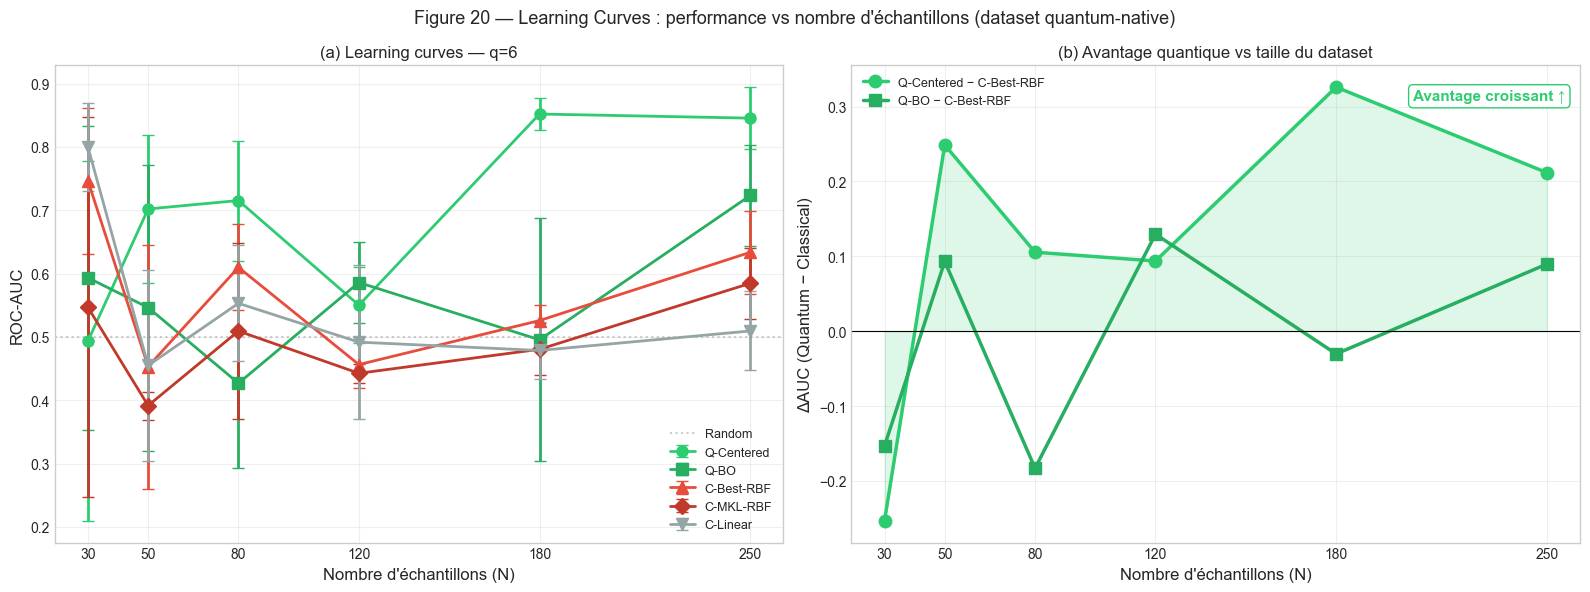


=== Learning Curves Summary ===
    N |   Q-Centered |         Q-BO |   C-Best-RBF |    Delta
------------------------------------------------------------
   30 |       0.4933 |       0.5933 |       0.7467 |  -0.2533
   50 |       0.7020 |       0.5463 |       0.4531 |  +0.2488
   80 |       0.7153 |       0.4267 |       0.6097 |  +0.1055
  120 |       0.5500 |       0.5858 |       0.4562 |  +0.0937
  180 |       0.8519 |       0.4954 |       0.5257 |  +0.3261
  250 |       0.8454 |       0.7232 |       0.6335 |  +0.2118

[4614s] Figure 20 done


In [51]:
# ── FIGURE 20 : Learning Curves — avantage quantique vs N ────────────────────
# Vary the number of training samples and measure quantum vs classical performance
# on the quantum-native dataset (Huang et al. 2021).

LC_N_VALUES = [30, 50, 80, 120, 180, 250]
LC_NQUBITS = N_QUBITS  # same as §9 (default 6)
LC_N_CV = 3

lc_results = {
    'Q-Centered': {}, 'Q-BO': {},
    'C-Best-RBF': {}, 'C-MKL-RBF': {}, 'C-Linear': {}
}

for n_samp in LC_N_VALUES:
    print(f'\n--- N = {n_samp} ---')
    t_lc = time.time()

    # Generate quantum-advantage dataset at this size
    X_lc, y_lc, _ = generate_quantum_advantage_dataset(
        n_samples=n_samp, n_qubits=LC_NQUBITS, feature_map_name='ZZ',
        alpha=1.0, reps=2, complexity=0.5, noise=0.03, random_state=SEED
    )

    # Quantum kernels
    fm_lib_lc = get_feature_map_library(LC_NQUBITS)
    qk_list_lc = [build_quantum_kernel(fm) for fm in fm_lib_lc.values()]
    K_q_lc = compute_kernel_matrix_parallel(
        qk_list_lc, X_lc,
        kernel_names=[f'lc_{n_samp}_{n}' for n in fm_lib_lc.keys()],
        n_jobs=-1
    )

    # Classical RBF kernels
    K_rbf_lc = [rbf_kernel(X_lc, gamma=g) for g in GAMMAS]

    skf_lc = StratifiedKFold(n_splits=LC_N_CV, shuffle=True, random_state=SEED)

    # ── Q-Centered ──
    r = eval_on_qa(K_q_lc, y_lc, weight_fn_centered)
    lc_results['Q-Centered'][n_samp] = r
    print(f'  Q-Centered : {r["mean"]:.4f} ± {r["std"]:.4f}')

    # ── Q-BO (lightweight: 15 calls) ──
    bo_aucs = []
    for tr, te in skf_lc.split(np.zeros(len(y_lc)), y_lc):
        K_tr = [K[np.ix_(tr, tr)] for K in K_q_lc]
        K_te = [K[np.ix_(te, tr)] for K in K_q_lc]
        bo = BayesianKernelOptimizer(n_calls=15, n_initial_points=8, cv_folds=3, random_state=SEED)
        w, C = bo.optimize(K_tr, y_lc[tr])
        Kc_tr = sum(wi * K for wi, K in zip(w, K_tr))
        Kc_te = sum(wi * K for wi, K in zip(w, K_te))
        ev = np.linalg.eigvalsh(Kc_tr)
        if ev.min() < 0:
            Kc_tr += (abs(ev.min()) + 1e-10) * np.eye(Kc_tr.shape[0])
        svm = SVC(kernel='precomputed', C=C, probability=True)
        svm.fit(Kc_tr, y_lc[tr])
        bo_aucs.append(roc_auc_score(y_lc[te], svm.predict_proba(Kc_te)[:, 1]))
    lc_results['Q-BO'][n_samp] = {
        'mean': np.mean(bo_aucs), 'std': np.std(bo_aucs, ddof=1), 'scores': bo_aucs
    }
    print(f'  Q-BO       : {lc_results["Q-BO"][n_samp]["mean"]:.4f} ± {lc_results["Q-BO"][n_samp]["std"]:.4f}')

    # ── C-Best-RBF (grid search gamma) ──
    best_auc_rbf, best_scores_rbf = 0, []
    for g in GAMMAS:
        aucs_g = []
        for tr, te in skf_lc.split(np.zeros(len(y_lc)), y_lc):
            svm = SVC(kernel='rbf', C=1.0, gamma=g, probability=True)
            svm.fit(X_lc[tr], y_lc[tr])
            aucs_g.append(roc_auc_score(y_lc[te], svm.predict_proba(X_lc[te])[:, 1]))
        if np.mean(aucs_g) > best_auc_rbf:
            best_auc_rbf = np.mean(aucs_g)
            best_scores_rbf = aucs_g
    lc_results['C-Best-RBF'][n_samp] = {
        'mean': best_auc_rbf, 'std': np.std(best_scores_rbf, ddof=1), 'scores': best_scores_rbf
    }
    print(f'  C-Best-RBF : {best_auc_rbf:.4f}')

    # ── C-MKL-RBF (Centered on RBF kernels) ──
    r_c = eval_on_qa(K_rbf_lc, y_lc, weight_fn_centered)
    lc_results['C-MKL-RBF'][n_samp] = r_c
    print(f'  C-MKL-RBF  : {r_c["mean"]:.4f} ± {r_c["std"]:.4f}')

    # ── C-Linear ──
    from sklearn.calibration import CalibratedClassifierCV
    lin_aucs = []
    for tr, te in skf_lc.split(np.zeros(len(y_lc)), y_lc):
        base = LinearSVC(C=1.0, max_iter=5000, dual=True)
        cal = CalibratedClassifierCV(base, cv=3)
        cal.fit(X_lc[tr], y_lc[tr])
        lin_aucs.append(roc_auc_score(y_lc[te], cal.predict_proba(X_lc[te])[:, 1]))
    lc_results['C-Linear'][n_samp] = {
        'mean': np.mean(lin_aucs), 'std': np.std(lin_aucs, ddof=1), 'scores': lin_aucs
    }
    print(f'  C-Linear   : {np.mean(lin_aucs):.4f}')

    print(f'  [{time.time() - t_lc:.0f}s]')

# ── Plot F20 : Learning Curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_lc = {
    'Q-Centered': '#2ecc71', 'Q-BO': '#27ae60',
    'C-Best-RBF': '#e74c3c', 'C-MKL-RBF': '#c0392b', 'C-Linear': '#95a5a6'
}
markers_lc = {
    'Q-Centered': 'o', 'Q-BO': 's',
    'C-Best-RBF': '^', 'C-MKL-RBF': 'D', 'C-Linear': 'v'
}

# (a) AUC vs N
ax = axes[0]
for method in lc_results:
    ns = sorted(lc_results[method].keys())
    means_m = [lc_results[method][n]['mean'] for n in ns]
    stds_m = [lc_results[method][n]['std'] for n in ns]
    ax.errorbar(ns, means_m, yerr=stds_m,
                fmt=f'{markers_lc[method]}-', color=colors_lc[method],
                linewidth=2, markersize=8, capsize=4, label=method)

ax.axhline(0.5, color='grey', linestyle=':', alpha=0.4, label='Random')
ax.set_xlabel('Nombre d\'échantillons (N)', fontsize=12)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title(f'(a) Learning curves — q={LC_NQUBITS}', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xticks(LC_N_VALUES)

# (b) Delta (quantum advantage) vs N
ax = axes[1]
ns = sorted(LC_N_VALUES)
delta_cent = [lc_results['Q-Centered'][n]['mean'] - lc_results['C-Best-RBF'][n]['mean'] for n in ns]
delta_bo = [lc_results['Q-BO'][n]['mean'] - lc_results['C-Best-RBF'][n]['mean'] for n in ns]

ax.plot(ns, delta_cent, 'o-', color='#2ecc71', linewidth=2.5, markersize=9, label='Q-Centered − C-Best-RBF')
ax.plot(ns, delta_bo, 's-', color='#27ae60', linewidth=2.5, markersize=9, label='Q-BO − C-Best-RBF')
ax.fill_between(ns, delta_cent, alpha=0.15, color='#2ecc71')
ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlabel('Nombre d\'échantillons (N)', fontsize=12)
ax.set_ylabel('ΔAUC (Quantum − Classical)', fontsize=12)
ax.set_title('(b) Avantage quantique vs taille du dataset', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(LC_N_VALUES)

# Annotate trend
if delta_cent[-1] > delta_cent[0]:
    trend_txt = 'Avantage croissant ↑'
    trend_col = '#2ecc71'
elif abs(delta_cent[-1] - delta_cent[0]) < 0.03:
    trend_txt = 'Avantage stable →'
    trend_col = '#3498db'
else:
    trend_txt = 'Avantage décroissant ↓'
    trend_col = '#e67e22'
ax.text(0.98, 0.95, trend_txt, transform=ax.transAxes, ha='right', va='top',
        fontsize=11, fontweight='bold', color=trend_col,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=trend_col))

plt.suptitle('Figure 20 — Learning Curves : performance vs nombre d\'échantillons (dataset quantum-native)',
             fontsize=13)
plt.tight_layout()
plt.savefig('../results/06/F20_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print('\n=== Learning Curves Summary ===')
print(f'{"N":>5s} | {"Q-Centered":>12s} | {"Q-BO":>12s} | {"C-Best-RBF":>12s} | {"Delta":>8s}')
print('-' * 60)
for n in ns:
    qc = lc_results['Q-Centered'][n]['mean']
    qb = lc_results['Q-BO'][n]['mean']
    cb = lc_results['C-Best-RBF'][n]['mean']
    print(f'{n:5d} | {qc:12.4f} | {qb:12.4f} | {cb:12.4f} | {qc - cb:+8.4f}')

print(f'\n[{time.time()-T_START:.0f}s] Figure 20 done')

## §8 — Synthèse

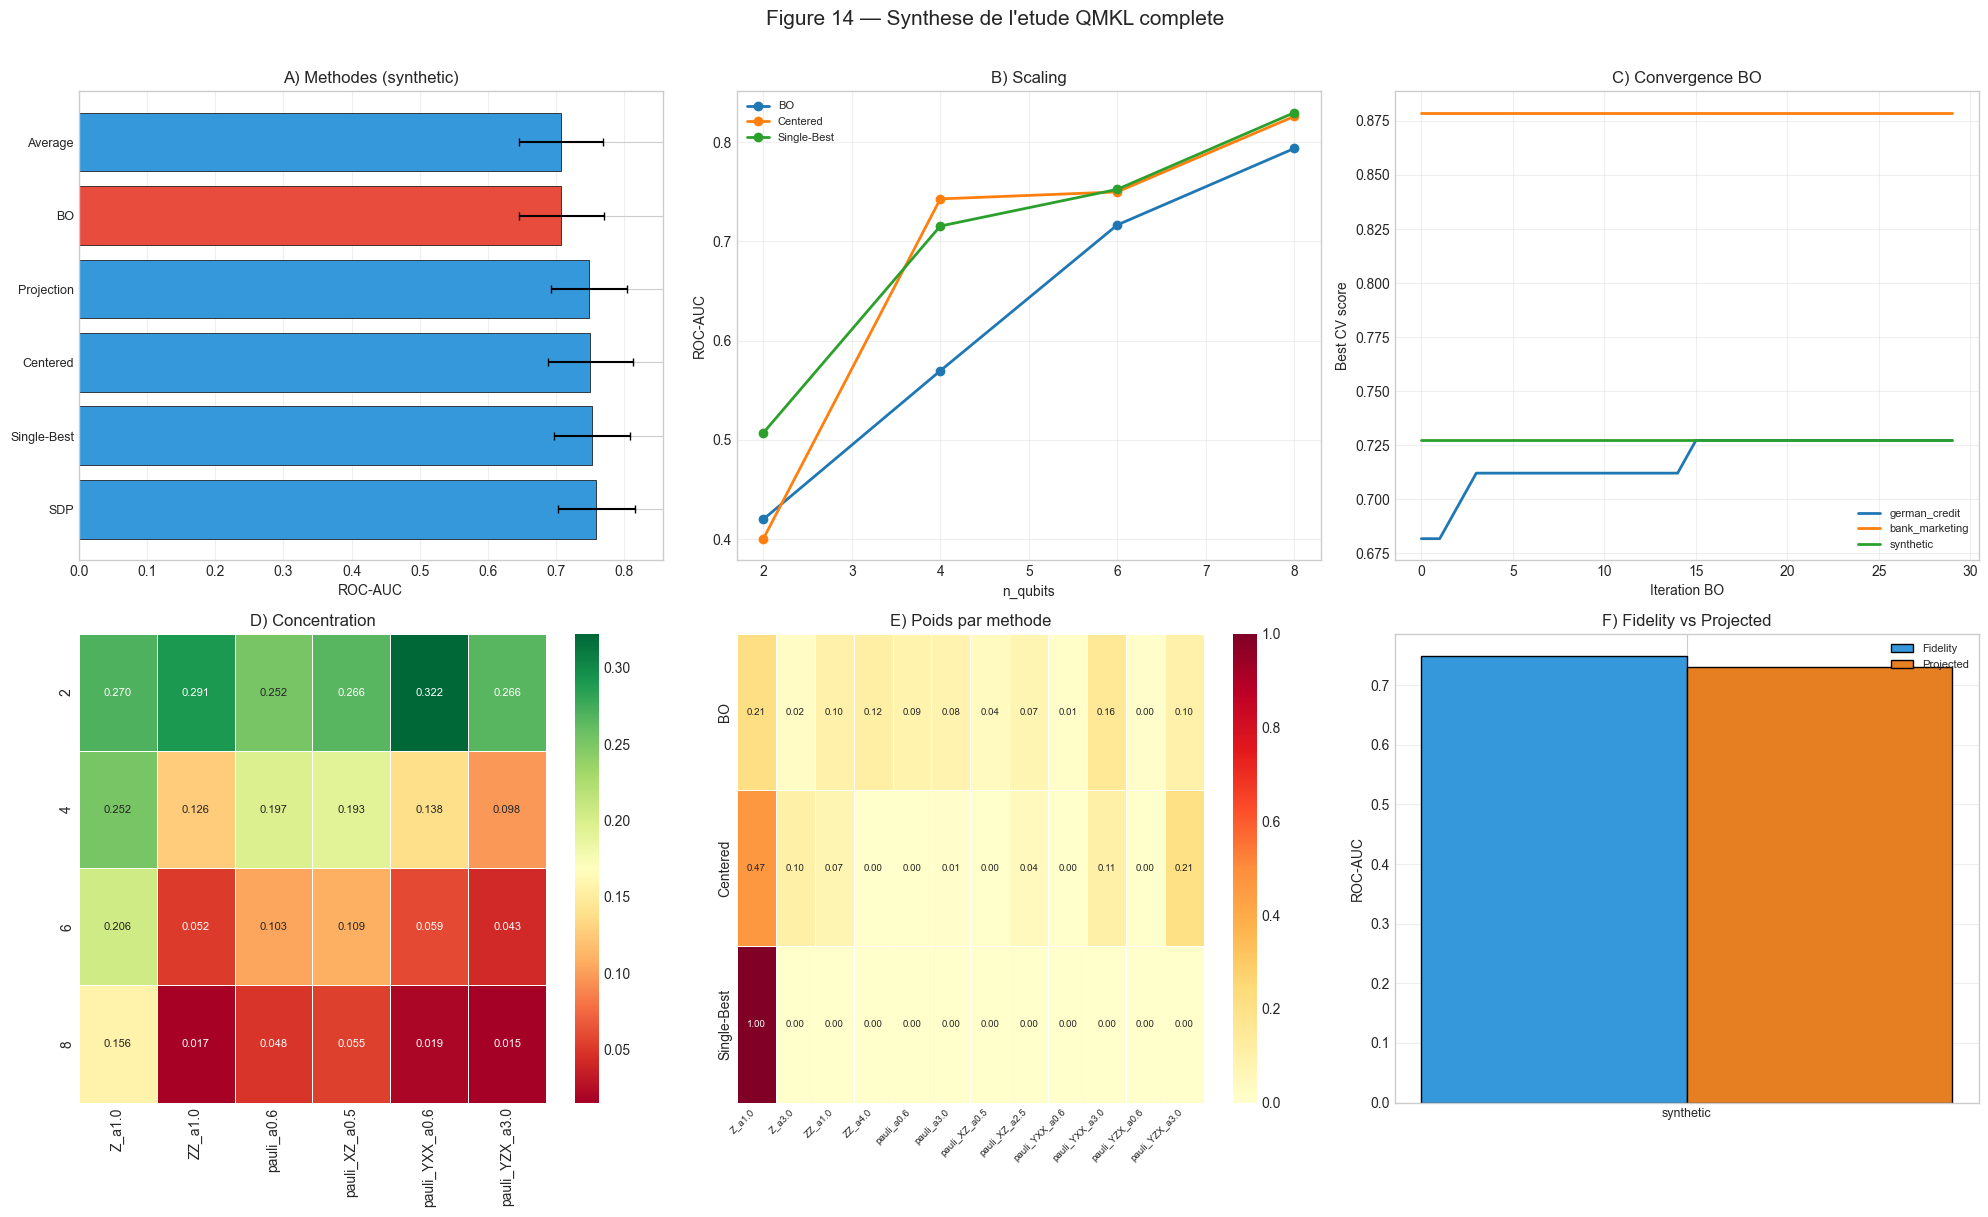

In [52]:
# ── FIGURE 14 : Panel de synthèse 2×3 ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# (0,0) Method comparison — synthetic
ax = axes[0, 0]
methods_sorted = sorted(ALL_RESULTS['synthetic'].keys(),
                        key=lambda m: ALL_RESULTS['synthetic'][m]['mean'], reverse=True)
vals = [ALL_RESULTS['synthetic'][m]['mean'] for m in methods_sorted]
errs = [ALL_RESULTS['synthetic'][m]['std'] for m in methods_sorted]
colors_bar = ['#e74c3c' if 'BO' in m else '#3498db' for m in methods_sorted]
ax.barh(range(len(methods_sorted)), vals, xerr=errs, color=colors_bar,
        edgecolor='black', linewidth=0.5, capsize=3)
ax.set_yticks(range(len(methods_sorted)))
ax.set_yticklabels(methods_sorted, fontsize=9)
ax.set_xlabel('ROC-AUC')
ax.set_title('A) Methodes (synthetic)')
ax.grid(axis='x', alpha=0.3)

# (0,1) Scaling curve
ax = axes[0, 1]
for method in scaling_results:
    nqs = sorted(scaling_results[method].keys())
    means = [scaling_results[method][nq]['mean'] for nq in nqs]
    ax.plot(nqs, means, 'o-', linewidth=2, markersize=6, label=method)
ax.set_xlabel('n_qubits')
ax.set_ylabel('ROC-AUC')
ax.set_title('B) Scaling')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (0,2) BO convergence
ax = axes[0, 2]
conv_histories = {ds: BO_HISTORIES[ds][0] for ds in BO_HISTORIES}
for ds_name_h, h in conv_histories.items():
    ax.plot(h['best_so_far'], '-', linewidth=2, label=ds_name_h)
ax.set_xlabel('Iteration BO')
ax.set_ylabel('Best CV score')
ax.set_title('C) Convergence BO')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (1,0) Concentration heatmap (subset)
ax = axes[1, 0]
subset_k = np.linspace(0, len(KNAMES)-1, min(6, len(KNAMES)), dtype=int)
sns.heatmap(conc_data[:, subset_k], annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=[KNAMES[i] for i in subset_k],
            yticklabels=[str(nq) for nq in QUBIT_RANGE],
            ax=ax, linewidths=0.5, annot_kws={'fontsize': 8})
ax.set_title('D) Concentration')

# (1,1) Weight heatmap (subset methods)
ax = axes[1, 1]
W_sub = {}
for m in ['BO', 'Centered', 'Single-Best']:
    if m in ALL_RESULTS['synthetic'] and ALL_RESULTS['synthetic'][m]['mean_weights'] is not None:
        W_sub[m] = ALL_RESULTS['synthetic'][m]['mean_weights']
W_arr = np.array([W_sub[m] for m in W_sub])
sns.heatmap(W_arr, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=KNAMES, yticklabels=list(W_sub.keys()),
            ax=ax, linewidths=0.5, annot_kws={'fontsize': 7})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_title('E) Poids par methode')

# (1,2) Fidelity vs Projected
ax = axes[1, 2]
ds_list = list(fid_vs_proj.keys())
x = np.arange(len(ds_list))
ax.bar(x - 0.17, [fid_vs_proj[d]['fidelity']['mean'] for d in ds_list], 0.34,
       label='Fidelity', color='#3498db', edgecolor='black')
ax.bar(x + 0.17, [fid_vs_proj[d]['projected']['mean'] for d in ds_list], 0.34,
       label='Projected', color='#e67e22', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(ds_list, fontsize=9)
ax.set_ylabel('ROC-AUC')
ax.set_title('F) Fidelity vs Projected')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Figure 14 — Synthese de l\'etude QMKL complete', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('../results/06/F14_synthesis_panel.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Tableau récapitulatif final ───────────────────────────────────────────────
total_time = time.time() - T_START
print(f'\n{"="*80}')
print(f'TABLEAU RECAPITULATIF — ROC-AUC (mean +/- std)')
print(f'{"="*80}')

# Quantum methods on financial datasets
rows = []
for ds_name in ALL_RESULTS:
    for method in ALL_RESULTS[ds_name]:
        r = ALL_RESULTS[ds_name][method]
        rows.append({'Dataset': ds_name, 'Method': f'Q-{method}',
                     'AUC_mean': r['mean'], 'AUC_std': r['std']})

# Classical baselines on financial datasets
for ds_name in CLASSICAL_RESULTS:
    for method in CLASSICAL_RESULTS[ds_name]:
        r = CLASSICAL_RESULTS[ds_name][method]
        rows.append({'Dataset': ds_name, 'Method': f'C-{method}',
                     'AUC_mean': r['mean'], 'AUC_std': r['std']})

df_summary = pd.DataFrame(rows)
df_pivot = df_summary.pivot(index='Method', columns='Dataset', values='AUC_mean')
df_pivot_std = df_summary.pivot(index='Method', columns='Dataset', values='AUC_std')

display_df = df_pivot.copy()
for col in display_df.columns:
    display_df[col] = [f'{m:.3f}+/-{s:.3f}' for m, s in
                        zip(df_pivot[col], df_pivot_std[col])]

print(display_df.to_string())

print('\nMeilleure methode par dataset :')
for col in df_pivot.columns:
    best = df_pivot[col].idxmax()
    val = df_pivot.loc[best, col]
    tag = 'QUANTIQUE' if best.startswith('Q-') else 'CLASSIQUE'
    print(f'  {col}: {best} ({val:.4f}) [{tag}]')

# Statistical significance summary
print('\n--- Significativite statistique ---')
if 'pvals' in dir():
    sig_pairs = [(a, b) for a in method_names for b in method_names
                 if a != b and pvals[a][b] < 0.05]
    if sig_pairs:
        for a, b in sig_pairs:
            print(f'  {a} > {b}: p={pvals[a][b]:.4f}')
    else:
        print('  Aucune difference significative detectee (p > 0.05)')

# Quantum advantage summary
print('\n--- Avantage quantique (dataset Huang et al.) ---')
if 'QA_RESULTS' in dir():
    for name, r in QA_RESULTS.items():
        print(f'  {name}: AUC = {r["mean"]:.3f} +/- {r["std"]:.3f}')
    q_best = max((r['mean'], n) for n, r in QA_RESULTS.items() if n.startswith('Q-'))
    c_best = max((r['mean'], n) for n, r in QA_RESULTS.items() if n.startswith('C-'))
    delta = q_best[0] - c_best[0]
    print(f'  => Delta quantique: {delta:+.3f} ({q_best[1]} vs {c_best[1]})')

# Learning curves summary
print('\n--- Learning Curves (dataset quantum-native) ---')
if 'lc_results' in dir():
    print(f'{"N":>5s} | {"Q-Centered":>12s} | {"C-Best-RBF":>12s} | {"Delta":>8s}')
    print('-' * 45)
    for n in sorted(lc_results['Q-Centered'].keys()):
        qc = lc_results['Q-Centered'][n]['mean']
        cb = lc_results['C-Best-RBF'][n]['mean']
        print(f'{n:5d} | {qc:12.4f} | {cb:12.4f} | {qc-cb:+8.4f}')

print(f'\nTemps total : {total_time/60:.1f} minutes')
print(f'Cache final : {cache_info()["files"]} fichiers ({cache_info()["total_size_mb"]:.1f} MB)')
print('\n20 figures sauvees dans results/06/')


TABLEAU RECAPITULATIF — ROC-AUC (mean +/- std)
Dataset        bank_marketing  german_credit      synthetic
Method                                                     
C-Linear SVM    0.890+/-0.082  0.569+/-0.093  0.740+/-0.029
C-MKL-RBF (CA)  0.862+/-0.104  0.740+/-0.045  0.556+/-0.310
C-RBF (g=0.1)   0.574+/-0.469      nan+/-nan  0.764+/-0.049
C-RBF (g=10.0)      nan+/-nan  0.554+/-0.242      nan+/-nan
Q-Average       0.612+/-0.314  0.683+/-0.061  0.707+/-0.061
Q-BO            0.793+/-0.046  0.669+/-0.061  0.708+/-0.062
Q-Centered      0.861+/-0.040  0.519+/-0.107  0.750+/-0.062
Q-Projection    0.653+/-0.210  0.552+/-0.323  0.748+/-0.056
Q-SDP           0.412+/-0.190  0.544+/-0.354  0.759+/-0.057
Q-Single-Best   0.553+/-0.165  0.336+/-0.290  0.753+/-0.056

Meilleure methode par dataset :
  bank_marketing: C-Linear SVM (0.8899) [CLASSIQUE]
  german_credit: C-MKL-RBF (CA) (0.7402) [CLASSIQUE]
  synthetic: C-RBF (g=0.1) (0.7639) [CLASSIQUE]

--- Significativite statistique ---
  Single-

: 